<a href="https://colab.research.google.com/github/samrudhisinghk/Road_Safety_Model_Submission/blob/main/AnalyticalModelTeamGroot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Road Safety Analysis: Maharashtra and Thailand

In [41]:
import geopandas as gpd
import time
import numpy as np
import pandas as pd
!pip install openmeteo-requests requests-cache retry-requests pyproj catboost
import openmeteo_requests
import requests_cache
from retry_requests import retry
from pyproj import Geod
from shapely.geometry import Point
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_predict, KFold
from sklearn.base import clone
from sklearn.dummy import DummyRegressor
from catboost import CatBoostRegressor
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.6 MB/s eta 0:00:00


#Loading Datasets

In [44]:
#!ls '/content/drive/My Drive/'

In [45]:
!ls '/content/drive/My Drive/AI for Safer Roads 2026 - Dataset/'
#accessing the dataset folder shortcut from my drive

 ADB_Innovation_Maharashtra.geojson
 ADB_Innovation_Thailand.geojson
'AI for Safer Roads 2026 - Data User Guide v1.0.pdf'
 Archive


In [48]:
#Loading a GeoJSON file from Google Drive
file_path = '/content/ADB_Innovation_Maharashtra.geojson'
gdf_maharastra = gpd.read_file(file_path)
print(gdf_maharastra.shape)

(14082, 28)


#Cleaning the Datasets

Road_length, Percent_, For_analysis, SpeedlimitFloor,  ProvinceID, NO_OF_Result_Segments are all atttributes to be ignored

##Maharashtra Dataset

In [49]:
gdf_maharastra.set_crs(epsg=4326, inplace=True)
if 'OBJECTID' in gdf_maharastra.columns:
    gdf_maharastra.set_index('OBJECTID', inplace=True)

In [56]:
gdf_maharastra

,DISSOLVE_ID,class,subtype,names_primary,UrbanPC,SampleSize_avg,RoadLength,WeightedSample,Percent_,Percentile,...,ExcludeFromSpeedSPI,PercentileBand,RankedPercentile,Sample_Size_Total,SpeedLimitFloor,PercentOverLimit,AnalysisStatus,StreetImageLink,Shape_Length,geometry
OBJECTID,,,,,,,,,,,,,,,,,,,,,
1,SE/4183,secondary,road,None,0.0,0.0,5.872279,0.000000,0.000000e+00,0.000000e+00,...,1.0,0-5%,0.000249,0.0,NaN,0.0,Valid,"73.5544591,16.2774648,73.53445,16.2401913",5872.278972,"LINESTRING (73.55446 16.27746, 73.5543 16.2770..."
2,SE/6376,secondary,road,None,0.0,0.5,5.900951,2.950476,1.704414e-09,1.704414e-09,...,0.0,0-5%,0.000499,1.0,55.0,0.0,Valid,"73.9651122,21.0463691,73.9910297,21.0647687",5900.951225,"LINESTRING (73.96511 21.04637, 73.96506 21.047..."
3,SE/8617,secondary,road,None,0.0,1.0,3.496819,3.496819,2.020023e-09,3.724438e-09,...,1.0,0-5%,0.000748,2.0,NaN,0.0,Valid,"74.9005386,19.0351416,74.8847951,19.020001",3496.819447,"LINESTRING (74.90054 19.03514, 74.90002 19.034..."
4,SE/10875,secondary,road,उमरी रोड,0.0,2.0,2.061238,4.122477,2.381449e-09,6.105887e-09,...,0.0,0-5%,0.000998,4.0,55.0,0.0,Valid,"76.593981,19.1964024,76.6112397,19.1893524",2061.238294,"LINESTRING (76.59398 19.1964, 76.59432 19.1959..."
5,SE/5916,secondary,road,None,0.0,1.0,4.845749,4.845749,2.799266e-09,8.905153e-09,...,0.0,0-5%,0.001247,6.0,55.0,0.0,Valid,"76.0436565,17.370428,76.0713028,17.3902438",4845.749302,"LINESTRING (76.04366 17.37043, 76.04393 17.370..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14078,TR/14072,trunk,road,नागपूर आदिलाबाद रोड,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,None,NaN,NaN,NaN,NaN,Not Included,"78.7178202,20.3052028,78.716014,20.3447203",4820.487061,"LINESTRING (78.71782 20.3052, 78.71813 20.3057..."
14079,TR/14073,trunk,road,नागपूर काटोल रोड,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,None,NaN,NaN,NaN,NaN,Not Included,"79.0312444,21.1845424,78.9972956,21.2022297",4082.611725,"LINESTRING (79.03124 21.18454, 79.02993 21.185..."
14080,TR/14075,trunk,road,नागपूर तुळजापूर रोड,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,None,NaN,NaN,NaN,NaN,Not Included,"78.2891967,20.4293941,78.2242246,20.4049023",7433.239945,"LINESTRING (78.2892 20.42939, 78.28809 20.4290..."


In [50]:
#viewing null counts in gdf_maharastra
gdf_maharastra.isna().sum()

,0
DISSOLVE_ID,0
class,0
subtype,0
names_primary,10068
UrbanPC,10072
SampleSize_avg,10072
RoadLength,10072
WeightedSample,10072
Percent_,10072
Percentile,10072


In [58]:
#no empty geometries
gdf_maharastra.is_empty.sum()

np.int64(0)

##Thailand Dataset

In [52]:
# Example of loading a GeoJSON file from Google Drive
drive_file_path = '/content/drive/My Drive/AI for Safer Roads 2026 - Dataset/ADB_Innovation_Thailand.geojson'
gdf_thailand = gpd.read_file(drive_file_path)
gdf_thailand.set_crs(epsg=4326, inplace=True)
if 'OBJECTID' in gdf_thailand.columns:
    gdf_thailand.set_index('OBJECTID', inplace=True)
print(gdf_thailand.shape)

(55884, 26)


In [55]:
gdf_thailand

,english_ro,OvertureID,SampleSize_avg,RoadLength,WeightedSample,Percent_,Percentile,SpeedLimit,RoadClass,NumberOverLimit,...,InvPercentile,AnalysisStatus,RankedPercentile,StreetImageLink,LandUse,NO_OF_Result_Segments,PercentileBand,SampleSizeTotal,Shape_Length,geometry
OBJECTID,,,,,,,,,,,,,,,,,,,,,
1,Surin Ring Road,1,NaN,4.632086,NaN,NaN,NaN,NaN,primary,NaN,...,NaN,Not Included,NaN,"103.4699393,14.839138,103.43891053,14.86699584",None,NaN,None,NaN,4632.086492,"LINESTRING (103.46994 14.83914, 103.46967 14.8..."
2,Surin Ring Road,2,44479.6,2.300000,102303.08,0.000002,0.002591,66.0,primary,128017.0,...,0.997409,Valid,26.253458,"103.43891053,14.86699584,103.48332214,14.94166589",RURAL,1.0,0-5%,222398.0,11672.918346,"LINESTRING (103.43891 14.867, 103.4383 14.8677..."
3,Surin Ring Road,3,NaN,0.122010,NaN,NaN,NaN,NaN,primary,NaN,...,NaN,Not Included,NaN,"103.48332214,14.94166589,103.48440114,14.94199564",None,NaN,None,NaN,122.010111,"LINESTRING (103.48332 14.94167, 103.48405 14.9..."
4,Surin Ring Road,4,NaN,2.045467,NaN,NaN,NaN,NaN,primary,NaN,...,NaN,Not Included,NaN,"103.48440114,14.94199564,103.50325276,14.94199566",None,NaN,None,NaN,2045.467119,"LINESTRING (103.4844 14.942, 103.4846 14.94205..."
5,Surin Ring Road,5,NaN,2.028143,NaN,NaN,NaN,NaN,primary,NaN,...,NaN,Not Included,NaN,"103.50325276,14.94199566,103.5216215,14.9380875",None,NaN,None,NaN,2028.142985,"LINESTRING (103.50325 14.942, 103.5072 14.9411..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55880,Highway 307,55880,NaN,0.016544,NaN,NaN,NaN,NaN,secondary,NaN,...,NaN,Not Included,NaN,"100.5136118,13.9670581,100.5137646,13.9670484",None,NaN,None,NaN,16.543632,"LINESTRING (100.51361 13.96706, 100.51376 13.9..."
55881,Prasert Manukitch Road,55881,638376.0,3.600000,2298153.60,0.000044,0.080148,80.0,secondary,63838.0,...,0.919852,Valid,84.984440,"100.650012,13.8097719,100.6422591,13.8155889",URBAN,1.0,5-10%,638376.0,1058.343521,"LINESTRING (100.65001 13.80977, 100.65 13.8097..."
55882,Prasert Manukitch Road,55882,425882.0,3.600000,1533175.20,0.000029,0.059449,80.0,secondary,0.0,...,0.940551,Valid,80.005187,"100.642389,13.8157065,100.6761334,13.8137623",URBAN,1.0,5-10%,425882.0,4095.715924,"LINESTRING (100.64239 13.81571, 100.6429 13.81..."


In [54]:
gdf_thailand.isna().sum()

,0
english_ro,0
OvertureID,0
SampleSize_avg,44340
RoadLength,0
WeightedSample,44340
Percent_,44340
Percentile,44340
SpeedLimit,44288
RoadClass,0
NumberOverLimit,44340


In [59]:
#no empty geometries
gdf_thailand.is_empty.sum()

np.int64(0)

##Cleaning both

Deleting null values from these datasets does significantly reduce the size of the dataset, but since
1. Number of null values across attributes is too large for imputation
2. Computation for a 14000+ row dataset is beyond what current tools can handle,


it proves necessary.

In [60]:
gdf_maharastra.dropna(inplace=True)
gdf_thailand.dropna(inplace=True)

In [61]:
gdf_maharastra.shape

(920, 27)

In [62]:
gdf_thailand.shape

(11544, 26)

Also have to remove values where AnalysisStatus is not Valid

In [63]:
gdf_maharastra = gdf_maharastra[gdf_maharastra['AnalysisStatus'] == 'Valid']
gdf_thailand = gdf_thailand[gdf_thailand['AnalysisStatus'] == 'Valid']

In [64]:
gdf_maharastra.shape

(920, 27)

In [65]:
gdf_thailand.shape

(11544, 26)

Difference in number of attributes:

In [66]:
#comparing attributes of both gdfs

columns_maharastra = set(gdf_maharastra.columns)
columns_thailand = set(gdf_thailand.columns)

common_columns = columns_maharastra.intersection(columns_thailand)
unique_to_maharastra = columns_maharastra.difference(columns_thailand)
unique_to_thailand = columns_thailand.difference(columns_maharastra)

print(f"Common columns: {sorted(list(common_columns))}")
print(f"Columns unique to gdf_maharastra: {sorted(list(unique_to_maharastra))}")
print(f"Columns unique to gdf_thailand: {sorted(list(unique_to_thailand))}")

Common columns: ['AnalysisStatus', 'F85thPercentileSpeed', 'LandUse', 'MedianSpeed', 'NumberOverLimit', 'PercentOverLimit', 'Percent_', 'Percentile', 'PercentileBand', 'RankedPercentile', 'RoadClass', 'RoadLength', 'SampleSize_avg', 'Shape_Length', 'SpeedLimit', 'SpeedLimitFloor', 'StreetImageLink', 'WeightedSample', 'geometry']
Columns unique to gdf_maharastra: ['DISSOLVE_ID', 'ExcludeFromSpeedSPI', 'Pass', 'Sample_Size_Total', 'UrbanPC', 'class', 'names_primary', 'subtype']
Columns unique to gdf_thailand: ['ForAnalysis', 'InvPercentile', 'NO_OF_Result_Segments', 'OvertureID', 'ProvinceID', 'SampleSizeTotal', 'english_ro']


In [67]:
gdf_thailand['ForAnalysis'].unique()

array([ 66.,  70.,  30.,  90.,  80.,  85., 120.,  40.,   0.,  75.,  60.,
        50.,  83.,  56.,  88.,  65.,  86.,  87.,  82., 100.,  63.,  76.,
        89.,  64.,  78.,  73.,  20.,  84.,  72.,  81.,  42.,  46.,  77.,
        55., 105.,  45.,  71.,  68.,  52.,  67.,  53.])

In [68]:
gdf_maharastra['UrbanPC'].unique()

array([0.00000000e+00, 5.30147691e-01, 1.00000000e+00, 1.16228177e-02,
       2.43960189e-02, 2.89496112e-02, 3.59359533e-01, 6.32234035e-01,
       2.92305077e-02, 1.65234170e-02, 5.81146181e-02, 7.25148054e-01,
       1.93217921e-01, 2.36616330e-01, 7.75037282e-01, 1.01677728e-01,
       3.66022858e-03, 8.96850195e-01, 3.39594198e-01, 9.00598053e-01,
       6.76237811e-01, 1.78958712e-01, 4.57749763e-02, 6.28521352e-02,
       9.68264290e-01, 1.56477318e-02, 3.78704192e-02, 4.83431878e-01,
       4.20889703e-01, 8.23964687e-02, 3.27364056e-01, 8.01631912e-01,
       3.27910889e-01, 4.19655156e-01, 1.97096835e-01, 2.77088891e-01,
       3.85290465e-01, 1.39730433e-01, 1.30258859e-01, 6.91541028e-01,
       7.60456849e-02, 1.07017234e-01, 6.67826093e-01, 3.24280259e-02,
       6.97597534e-01, 4.54404906e-01, 6.57564099e-01, 9.89763825e-01,
       6.93649066e-01, 4.25956806e-02, 7.57647945e-01, 6.86328634e-02,
       5.74138870e-01, 6.59655239e-01, 5.02943634e-01, 7.15704528e-02,
      

In [69]:
#checking if two attributes are equivalent
if (gdf_maharastra['class'] == gdf_maharastra['RoadClass']).all():
  print('equivalent')
else:
  print('not equivalent')

equivalent


In [70]:
gdf_maharastra = gdf_maharastra.drop(['AnalysisStatus', 'DISSOLVE_ID', 'Pass', 'subtype', 'ExcludeFromSpeedSPI','class', 'RoadLength', 'SpeedLimitFloor','Percent_'], axis='columns')

In [71]:
columns_to_drop_thailand = ['NO_OF_Result_Segments', 'OvertureID', 'RoadLength', 'SpeedLimitFloor','Percent_']
#Filter out columns that do not exist in the DataFrame
existing_columns_to_drop_thailand = [col for col in columns_to_drop_thailand if col in gdf_thailand.columns]
gdf_thailand = gdf_thailand.drop(existing_columns_to_drop_thailand, axis='columns')

##Summary:

In [72]:
gdf_maharastra.describe()

,UrbanPC,SampleSize_avg,WeightedSample,Percentile,NumberOverLimit,MedianSpeed,F85thPercentileSpeed,RankedPercentile,Sample_Size_Total,PercentOverLimit,Shape_Length
count,920.000000,9.200000e+02,9.200000e+02,9.200000e+02,9.200000e+02,920.000000,920.000000,920.000000,9.200000e+02,920.000000,920.000000
mean,0.453953,2.610471e+05,7.796641e+05,1.161834e-01,5.667994e+05,42.217720,53.480421,0.626110,1.301719e+06,0.284963,7048.554335
std,0.463324,6.421820e+05,2.319867e+06,1.756717e-01,3.070741e+06,15.632790,17.870779,0.258844,4.819201e+06,0.306275,9090.086874
min,0.000000,2.000000e+00,4.122477e+00,6.105887e-09,0.000000e+00,12.333333,18.000000,0.000998,4.000000e+00,0.000000,557.269639
25%,0.000000,6.689094e+03,2.581246e+04,7.659311e-03,0.000000e+00,30.276786,39.666667,0.437095,1.954975e+04,0.000000,1380.750428
50%,0.214212,2.541383e+04,1.122058e+05,3.836363e-02,6.694500e+03,40.000000,52.000000,0.659352,8.368700e+04,0.162694,3451.241158
75%,1.000000,1.546916e+05,4.724518e+05,1.426266e-01,5.920925e+04,52.666667,65.647321,0.847569,4.708702e+05,0.512683,9141.764570
max,1.000000,4.894736e+06,2.602851e+07,1.000000e+00,5.196662e+07,86.500000,103.500000,1.000000,5.798907e+07,1.000000,76936.353132


In [73]:
gdf_thailand.describe()

,SampleSize_avg,WeightedSample,Percentile,SpeedLimit,NumberOverLimit,MedianSpeed,F85thPercentileSpeed,ForAnalysis,PercentOverLimit,InvPercentile,RankedPercentile,SampleSizeTotal,Shape_Length
count,1.154400e+04,1.154400e+04,11544.000000,11544.000000,1.154400e+04,11544.000000,11544.000000,11544.000000,11544.000000,11544.000000,11544.000000,1.154400e+04,11544.000000
mean,6.697560e+05,4.538416e+06,0.041609,80.550502,2.114311e+05,64.541280,78.281600,80.550502,0.218104,0.958391,49.900588,7.624473e+05,5250.958374
std,2.976403e+06,3.892524e+07,0.079694,18.444647,1.271425e+06,21.235044,23.803171,18.444647,0.246957,0.079694,28.808870,3.108397e+06,9178.055201
min,3.333333e+00,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.008645,8.000000e+00,22.150957
25%,6.813529e+04,9.543524e+04,0.002308,80.000000,0.000000e+00,53.718750,67.000000,80.000000,0.000000,0.955177,24.954616,9.844625e+04,783.552206
50%,1.772380e+05,3.104017e+05,0.012428,85.000000,2.046650e+04,67.900000,82.000000,85.000000,0.125001,0.987572,49.900588,2.162550e+05,1821.366197
75%,4.455252e+05,1.079965e+06,0.044823,90.000000,1.180442e+05,79.400000,94.500000,90.000000,0.374999,0.997692,74.846559,5.271355e+05,5385.550462
max,9.031018e+07,1.551703e+09,1.000000,120.000000,5.893935e+07,130.000000,150.000000,120.000000,1.000000,1.000000,99.792531,9.031018e+07,152218.413316


#Exploratory Data Analysis

In [74]:
print('Columns in gdf_maharastra:')
print(gdf_maharastra.columns.tolist())
print('\nColumns in gdf_thailand:')
print(gdf_thailand.columns.tolist())

Columns in gdf_maharastra:
['names_primary', 'UrbanPC', 'SampleSize_avg', 'WeightedSample', 'Percentile', 'SpeedLimit', 'RoadClass', 'LandUse', 'NumberOverLimit', 'MedianSpeed', 'F85thPercentileSpeed', 'PercentileBand', 'RankedPercentile', 'Sample_Size_Total', 'PercentOverLimit', 'StreetImageLink', 'Shape_Length', 'geometry']

Columns in gdf_thailand:
['english_ro', 'SampleSize_avg', 'WeightedSample', 'Percentile', 'SpeedLimit', 'RoadClass', 'NumberOverLimit', 'MedianSpeed', 'F85thPercentileSpeed', 'ForAnalysis', 'ProvinceID', 'PercentOverLimit', 'InvPercentile', 'AnalysisStatus', 'RankedPercentile', 'StreetImageLink', 'LandUse', 'PercentileBand', 'SampleSizeTotal', 'Shape_Length', 'geometry']


In [75]:
gdf_maharastra['PercentOverLimit'].value_counts()

,count
PercentOverLimit,
0.000000,258
1.000000,20
0.800000,2
0.023282,1
0.096733,1
...,...
0.412504,1
0.072974,1
0.392204,1


In [76]:
print("Correlation with 'PercentOverLimit' in gdf_maharastra:")
correlation_maharastra = gdf_maharastra.corr(numeric_only=True)['PercentOverLimit'].sort_values(ascending=False)
display(correlation_maharastra)

Correlation with 'PercentOverLimit' in gdf_maharastra:


,PercentOverLimit
PercentOverLimit,1.000000
F85thPercentileSpeed,0.641481
MedianSpeed,0.634927
NumberOverLimit,0.243864
RankedPercentile,0.182554
Sample_Size_Total,0.132839
Shape_Length,0.115774
SampleSize_avg,0.113560
Percentile,0.102974
WeightedSample,0.088990


In [77]:
print("\nCorrelation with 'PercentOverLimit' in gdf_thailand:")
correlation_thailand = gdf_thailand.corr(numeric_only=True)['PercentOverLimit'].sort_values(ascending=False)
display(correlation_thailand)


Correlation with 'PercentOverLimit' in gdf_thailand:


,PercentOverLimit
PercentOverLimit,1.000000
MedianSpeed,0.644722
F85thPercentileSpeed,0.631020
RankedPercentile,0.283580
Percentile,0.197237
NumberOverLimit,0.193959
SampleSizeTotal,0.058806
WeightedSample,0.054352
SampleSize_avg,0.052025
Shape_Length,0.041785


##EDA Plots


--- EDA Plots for Maharashtra (gdf_maharastra) ---


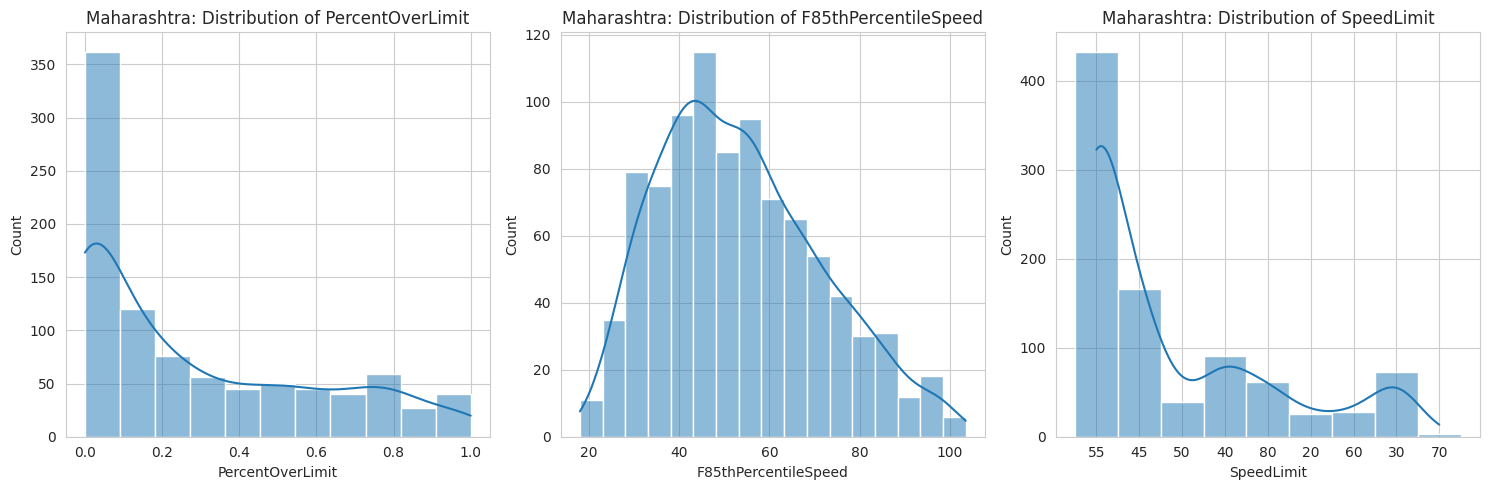

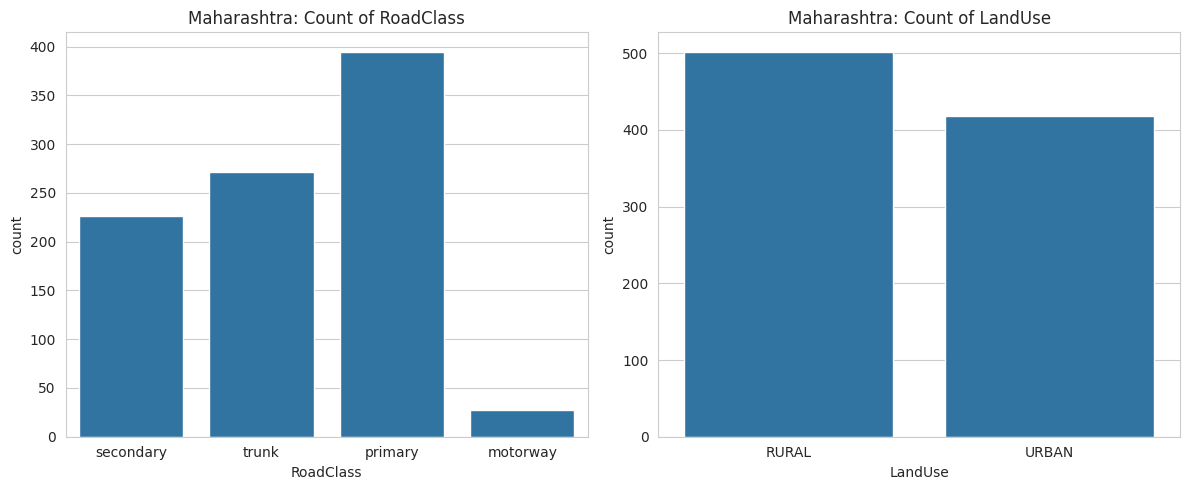

In [80]:

# --- Plots for gdf_maharastra ---
print("\n--- EDA Plots for Maharashtra (gdf_maharastra) ---")

# Set a style for better aesthetics
sns.set_style("whitegrid")

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.histplot(gdf_maharastra['PercentOverLimit'], kde=True)
plt.title('Maharashtra: Distribution of PercentOverLimit')

plt.subplot(1, 3, 2)
sns.histplot(gdf_maharastra['F85thPercentileSpeed'], kde=True)
plt.title('Maharashtra: Distribution of F85thPercentileSpeed')

plt.subplot(1, 3, 3)
sns.histplot(gdf_maharastra['SpeedLimit'], kde=True)
plt.title('Maharashtra: Distribution of SpeedLimit')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.countplot(data=gdf_maharastra, x='RoadClass')
plt.title('Maharashtra: Count of RoadClass')

plt.subplot(1, 2, 2)
sns.countplot(data=gdf_maharastra, x='LandUse')
plt.title('Maharashtra: Count of LandUse')
plt.tight_layout()
plt.show()




--- EDA Plots for Thailand (gdf_thailand) ---


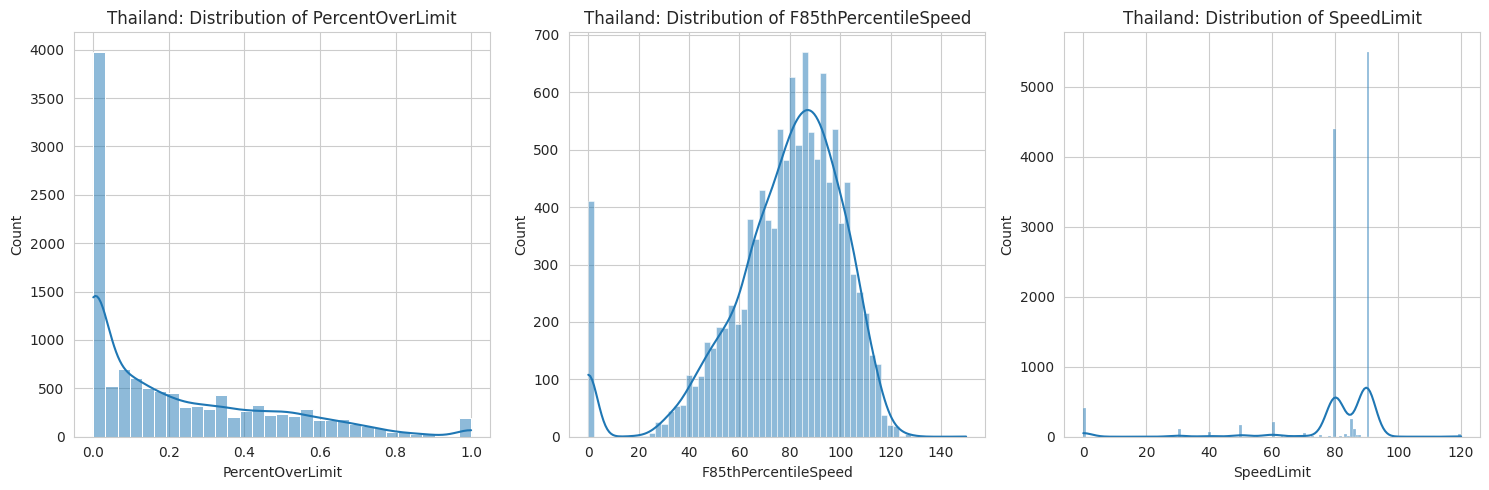

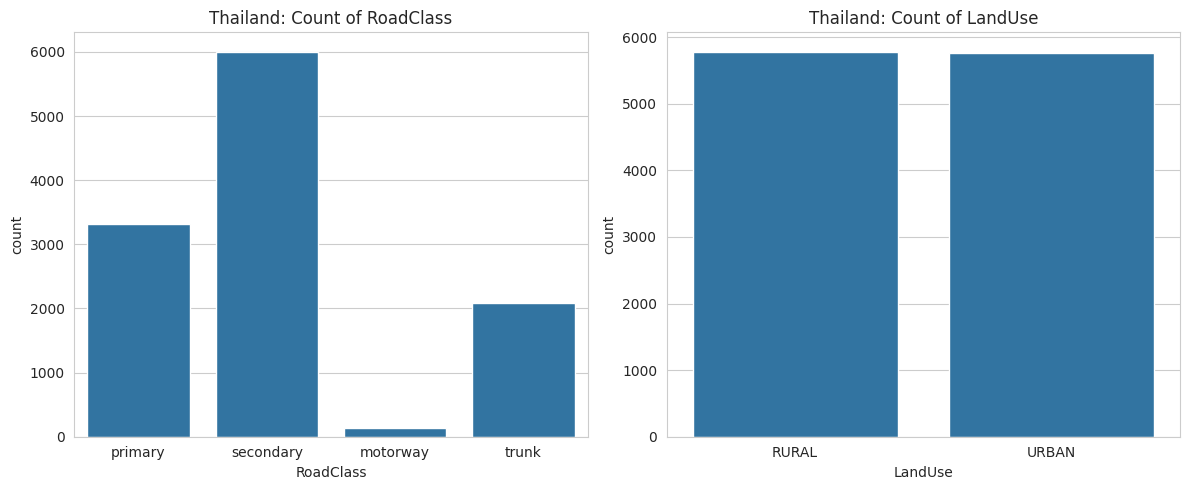

In [79]:
# --- Plots for gdf_thailand ---
print("\n--- EDA Plots for Thailand (gdf_thailand) ---")

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.histplot(gdf_thailand['PercentOverLimit'], kde=True)
plt.title('Thailand: Distribution of PercentOverLimit')

plt.subplot(1, 3, 2)
sns.histplot(gdf_thailand['F85thPercentileSpeed'], kde=True)
plt.title('Thailand: Distribution of F85thPercentileSpeed')

plt.subplot(1, 3, 3)
sns.histplot(gdf_thailand['SpeedLimit'], kde=True)
plt.title('Thailand: Distribution of SpeedLimit')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.countplot(data=gdf_thailand, x='RoadClass')
plt.title('Thailand: Count of RoadClass')

plt.subplot(1, 2, 2)
sns.countplot(data=gdf_thailand, x='LandUse')
plt.title('Thailand: Count of LandUse')
plt.tight_layout()
plt.show()

Observing the F85th Percentile speed limit distribution for Thailand, it appears that a lot of roads have vehicles travelling at a speed of zero!

In [83]:
#Checking observation
gdf_thailand[gdf_thailand['F85thPercentileSpeed'] == 0].shape[0]

410

Though this count could signify parked vehicles or road segments with heavy traffic, in the absence of traffic volume or similar data, these rows provide no additional insights and only skew data distributions

In [84]:
#Hence dropping these rows and redoing EDA plots
gdf_thailand = gdf_thailand[gdf_thailand['F85thPercentileSpeed'] != 0]


--- EDA Plots for Thailand (gdf_thailand) ---


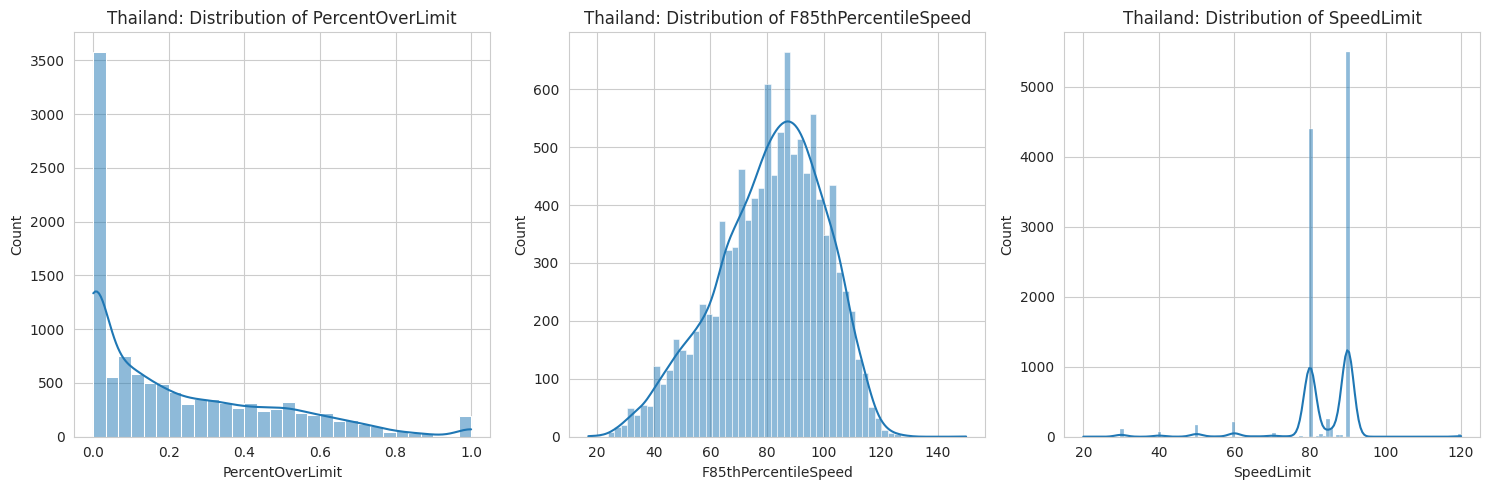

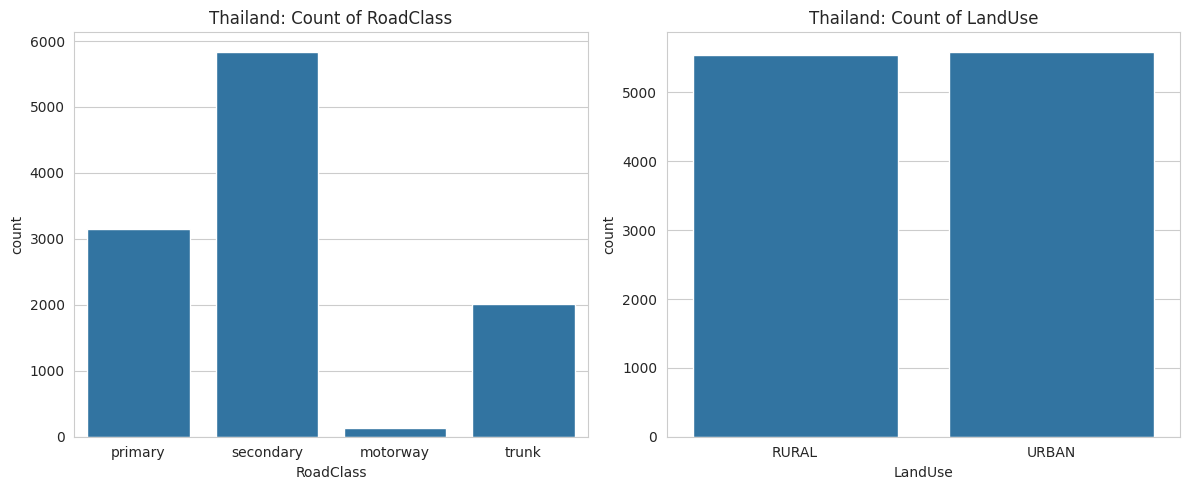

In [85]:
# --- Plots for gdf_thailand ---
print("\n--- EDA Plots for Thailand (gdf_thailand) ---")

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.histplot(gdf_thailand['PercentOverLimit'], kde=True)
plt.title('Thailand: Distribution of PercentOverLimit')

plt.subplot(1, 3, 2)
sns.histplot(gdf_thailand['F85thPercentileSpeed'], kde=True)
plt.title('Thailand: Distribution of F85thPercentileSpeed')

plt.subplot(1, 3, 3)
sns.histplot(gdf_thailand['SpeedLimit'], kde=True)
plt.title('Thailand: Distribution of SpeedLimit')
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.countplot(data=gdf_thailand, x='RoadClass')
plt.title('Thailand: Count of RoadClass')

plt.subplot(1, 2, 2)
sns.countplot(data=gdf_thailand, x='LandUse')
plt.title('Thailand: Count of LandUse')
plt.tight_layout()
plt.show()

#Checking VRU Index Output

In [86]:
gdf_vru=gpd.read_file("/content/maharashtra_vru_exposure_output(2).geojson")
gdf_vru.set_index('OBJECTID', inplace=True)
gdf_vru.set_crs(epsg=4326, inplace=True)

,DISSOLVE_ID,class,subtype,names_primary,UrbanPC,SampleSize_avg,RoadLength,WeightedSample,Percent_,Percentile,...,crossing_count,footfall_count,poi_density,crossing_density,footfall_density,poi_score,crossing_score,footfall_score,VRU_exposure_index,geometry
OBJECTID,,,,,,,,,,,,,,,,,,,,,
4,SE/10875,secondary,road,उमरी रोड,0.000000,2.000000e+00,2.061238,4.122477e+00,2.381449e-09,6.105887e-09,...,0,0,0.000000,0.00000,0.000000,0.258696,0.470109,0.266304,31.497283,"LINESTRING (76.59398 19.1964, 76.59432 19.1959..."
28,SE/10859,secondary,road,धामनगाव-कारेवाडी रोड,0.000000,4.600000e+01,1.110992,5.110563e+01,2.952242e-08,4.523761e-07,...,0,0,0.000000,0.00000,0.000000,0.258696,0.470109,0.266304,31.497283,"LINESTRING (76.8582 18.38425, 76.85783 18.3845..."
29,SE/10404,secondary,road,MDR11,0.000000,1.100000e+01,4.786672,5.265340e+01,3.041652e-08,4.827926e-07,...,0,6,0.208913,0.00000,1.253480,0.626087,0.470109,0.793478,66.241848,"LINESTRING (76.64185 18.20056, 76.64182 18.200..."
35,SE/10709,secondary,road,Shirur Anantpal- Shend-Devni Road,0.000000,5.162500e+01,1.364694,7.045233e+01,4.069851e-08,7.045237e-07,...,0,0,0.000000,0.00000,0.000000,0.258696,0.470109,0.266304,31.497283,"LINESTRING (76.89853 18.30244, 76.8986 18.3024..."
39,TR/13116,trunk,road,Bypass Road,0.000000,9.233333e+01,0.849862,7.847055e+01,4.533043e-08,8.779275e-07,...,0,0,0.000000,0.00000,0.000000,0.258696,0.470109,0.266304,31.497283,"LINESTRING (80.05606 19.4256, 80.05612 19.4259..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4004,TR/13312,trunk,road,Katraj - Dehu Road Bypass,0.861757,2.596752e+06,8.163017,2.119733e+07,1.224516e-02,9.203958e-01,...,0,21,0.245007,0.00000,2.572578,0.642391,0.470109,0.864130,69.910326,"LINESTRING (73.77466 18.54486, 73.77468 18.544..."
4005,PR/3067,primary,road,Kalyan - Shil Road,0.489939,1.768548e+06,12.135309,2.146188e+07,1.239798e-02,9.327938e-01,...,0,11,0.412021,0.00000,0.906446,0.700000,0.470109,0.748913,66.453804,"LINESTRING (73.04679 19.14316, 73.04685 19.143..."
4006,TR/13468,trunk,road,Nagar Road,1.000000,1.541945e+06,14.142924,2.180762e+07,1.259770e-02,9.453915e-01,...,3,56,4.171697,0.21212,3.959577,0.931522,0.950000,0.896739,92.048913,"LINESTRING (73.88478 18.54507, 73.88487 18.545..."


In [87]:
gdf_vru.describe()

,UrbanPC,SampleSize_avg,RoadLength,WeightedSample,Percent_,Percentile,NumberOverLimit,MedianSpeed,F85thPercentileSpeed,Pass,...,poi_count,crossing_count,footfall_count,poi_density,crossing_density,footfall_density,poi_score,crossing_score,footfall_score,VRU_exposure_index
count,920.000000,9.200000e+02,920.000000,9.200000e+02,9.200000e+02,9.200000e+02,9.200000e+02,920.000000,920.000000,920.0,...,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000,920.000000
mean,0.453953,2.610471e+05,7.048554,7.796641e+05,4.503920e-04,1.161834e-01,5.667994e+05,42.217720,53.480421,1.0,...,1.932609,0.413043,3.710870,0.803009,0.228211,1.667932,0.500543,0.500543,0.500543,50.054348
std,0.463324,6.421820e+05,9.090087,2.319867e+06,1.340128e-03,1.756717e-01,3.070741e+06,15.632790,17.870779,0.0,...,4.424167,4.092915,9.483913,1.725204,2.208779,5.269191,0.268220,0.119689,0.266264,18.445951
min,0.000000,2.000000e+00,0.557270,4.122477e+00,2.381449e-09,6.105887e-09,0.000000e+00,12.333333,18.000000,1.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.258696,0.470109,0.266304,31.497283
25%,0.000000,6.689094e+03,1.380750,2.581246e+04,1.491120e-05,7.659311e-03,0.000000e+00,30.276786,39.666667,1.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.258696,0.470109,0.266304,31.497283
50%,0.214212,2.541383e+04,3.451241,1.122058e+05,6.481843e-05,3.836363e-02,6.694500e+03,40.000000,52.000000,1.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.258696,0.470109,0.266304,46.619565
75%,1.000000,1.546916e+05,9.141765,4.724518e+05,2.729233e-04,1.426266e-01,5.920925e+04,52.666667,65.647321,1.0,...,2.000000,0.000000,2.000000,0.744662,0.000000,0.907333,0.750272,0.470109,0.750272,63.009511
max,1.000000,4.894736e+06,76.936353,2.602851e+07,1.503601e-02,1.000000e+00,5.196662e+07,86.500000,103.500000,1.0,...,60.000000,78.000000,66.000000,13.007083,38.287816,65.607921,1.000000,1.000000,1.000000,99.701087


In [88]:
gdf_vru.shape

(920, 38)

In [89]:
gdf_vru.head()

,DISSOLVE_ID,class,subtype,names_primary,UrbanPC,SampleSize_avg,RoadLength,WeightedSample,Percent_,Percentile,...,crossing_count,footfall_count,poi_density,crossing_density,footfall_density,poi_score,crossing_score,footfall_score,VRU_exposure_index,geometry
OBJECTID,,,,,,,,,,,,,,,,,,,,,
4,SE/10875,secondary,road,उमरी रोड,0.0,2.000000,2.061238,4.122477,2.381449e-09,6.105887e-09,...,0,0,0.000000,0.0,0.00000,0.258696,0.470109,0.266304,31.497283,"LINESTRING (76.59398 19.1964, 76.59432 19.1959..."
28,SE/10859,secondary,road,धामनगाव-कारेवाडी रोड,0.0,46.000000,1.110992,51.105629,2.952242e-08,4.523761e-07,...,0,0,0.000000,0.0,0.00000,0.258696,0.470109,0.266304,31.497283,"LINESTRING (76.8582 18.38425, 76.85783 18.3845..."
29,SE/10404,secondary,road,MDR11,0.0,11.000000,4.786672,52.653396,3.041652e-08,4.827926e-07,...,0,6,0.208913,0.0,1.25348,0.626087,0.470109,0.793478,66.241848,"LINESTRING (76.64185 18.20056, 76.64182 18.200..."
35,SE/10709,secondary,road,Shirur Anantpal- Shend-Devni Road,0.0,51.625000,1.364694,70.452334,4.069851e-08,7.045237e-07,...,0,0,0.000000,0.0,0.00000,0.258696,0.470109,0.266304,31.497283,"LINESTRING (76.89853 18.30244, 76.8986 18.3024..."
39,TR/13116,trunk,road,Bypass Road,0.0,92.333333,0.849862,78.470546,4.533043e-08,8.779275e-07,...,0,0,0.000000,0.0,0.00000,0.258696,0.470109,0.266304,31.497283,"LINESTRING (80.05606 19.4256, 80.05612 19.4259..."


##Some Plots

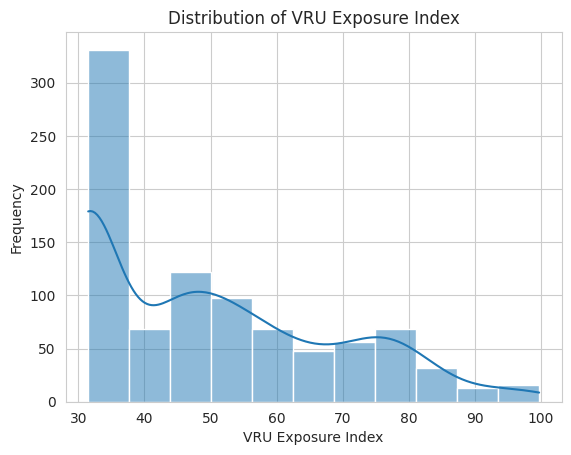

In [102]:
sns.histplot(gdf_vru['VRU_exposure_index'], kde=True)
plt.title('Distribution of VRU Exposure Index')
plt.xlabel('VRU Exposure Index')
plt.ylabel('Frequency')
plt.show()

Splitting the index into its component scores:

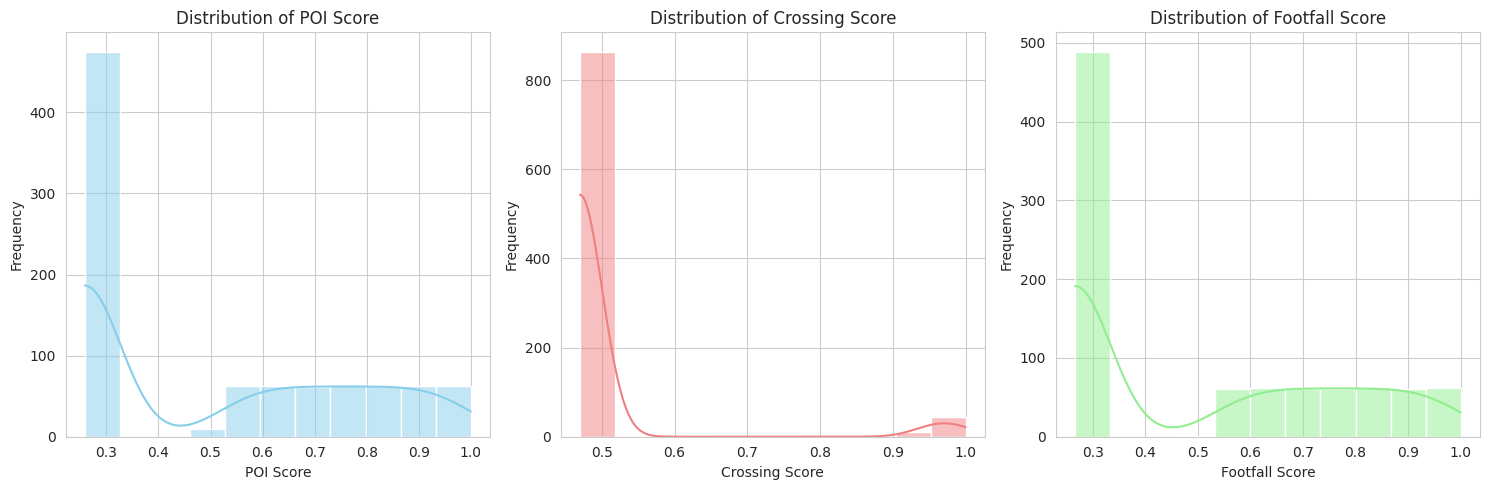

In [96]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.histplot(gdf_vru['poi_score'], kde=True, color='skyblue')
plt.title('Distribution of POI Score')
plt.xlabel('POI Score')
plt.ylabel('Frequency')

plt.subplot(1, 3, 2)
sns.histplot(gdf_vru['crossing_score'], kde=True, color='lightcoral')
plt.title('Distribution of Crossing Score')
plt.xlabel('Crossing Score')
plt.ylabel('Frequency')

plt.subplot(1, 3, 3)
sns.histplot(gdf_vru['footfall_score'], kde=True, color='lightgreen')
plt.title('Distribution of Footfall Score')
plt.xlabel('Footfall Score')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

As is expected, Urban areas with higher population density, have a higher Vulnerable Road User (VRU) Exposure Index.

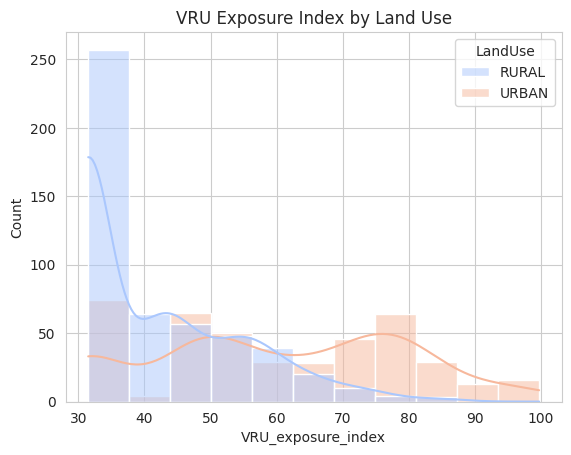

In [107]:
sns.histplot(data=gdf_vru, x='VRU_exposure_index', hue='LandUse', palette='coolwarm', kde=True)
plt.title('VRU Exposure Index by Land Use')
plt.show()

Looking at the Urban VRU index split by road class, we see the distinct bimodal pattern present only in primary and secondary roads more clearly. Trunks and Motorways have constant lower VRU exposure indices.

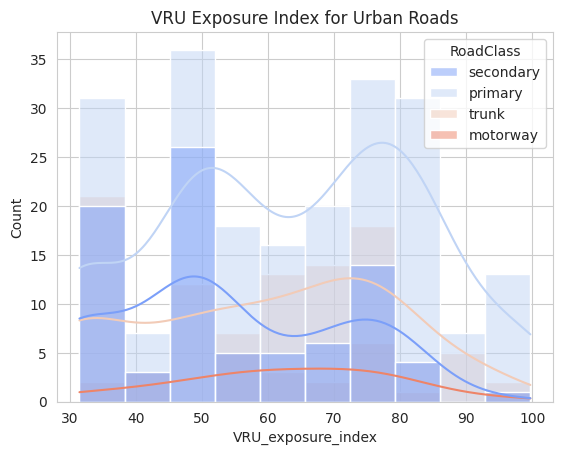

In [110]:
data=gdf_vru[gdf_vru['LandUse']=='URBAN']
sns.histplot(data=data, x='VRU_exposure_index', hue='RoadClass', palette='coolwarm', kde=True)
plt.title('VRU Exposure Index for Urban Roads')
plt.show()

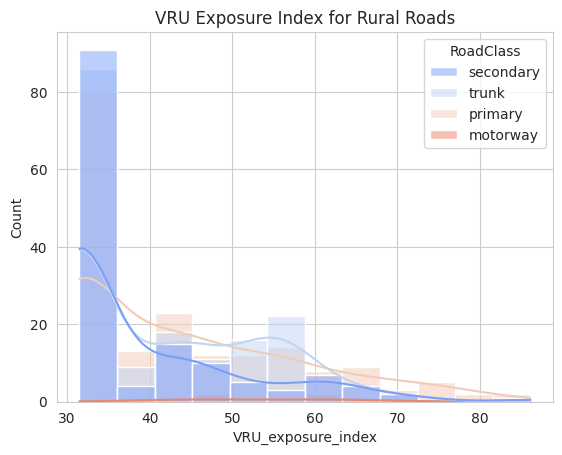

In [108]:
data=gdf_vru[gdf_vru['LandUse']=='RURAL']
sns.histplot(data=data, x='VRU_exposure_index', hue='RoadClass', palette='coolwarm', kde=True)
plt.title('VRU Exposure Index for Rural Roads')
plt.show()

##joining with gdf_maharastra

In [171]:
#Extracting relevant columns and adding it to gdf_maharastra
gdf_maharastra = gdf_maharastra.join(gdf_vru[['poi_score', 'crossing_score', 'footfall_score', 'VRU_exposure_index']])

In [172]:
gdf_vru.shape

(920, 38)

In [173]:
print(gdf_maharastra.head())

# Check for index mismatches after the join
maharastra_index = set(gdf_maharastra.index)
vru_index = set(gdf_vru.index)

missing_in_vru = maharastra_index - vru_index
missing_in_maharastra = vru_index - maharastra_index

if missing_in_vru:
    print(f"\n{len(missing_in_vru)} OBJECTIDs in gdf_maharastra do not have a match in gdf_vru. Examples: {list(missing_in_vru)[:5]}")
else:
    print("\nAll OBJECTIDs from gdf_maharastra are present in gdf_vru.")

if missing_in_maharastra:
    print(f"{len(missing_in_maharastra)} OBJECTIDs in gdf_vru do not have a match in gdf_maharastra. Examples: {list(missing_in_maharastra)[:5]}")
else:
    print("All OBJECTIDs from gdf_vru are present in gdf_maharastra.")

                           road_name  UrbanPC  SampleSize_avg  WeightedSample  \
0                           उमरी रोड      0.0        2.000000        4.122477   
1               धामनगाव-कारेवाडी रोड      0.0       46.000000       51.105629   
2                              MDR11      0.0       11.000000       52.653396   
3  Shirur Anantpal- Shend-Devni Road      0.0       51.625000       70.452334   
4                        Bypass Road      0.0       92.333333       78.470546   

     Percentile SpeedLimit  RoadClass LandUse  MedianSpeed  \
0  6.105887e-09         55  secondary   RURAL    13.000000   
1  4.523761e-07         55  secondary   RURAL    19.500000   
2  4.827926e-07         55  secondary   RURAL    19.500000   
3  7.045237e-07         55  secondary   RURAL    32.500000   
4  8.779275e-07         55      trunk   RURAL    22.333333   

   F85thPercentileSpeed  ... grid_lon  fog_warnings_count  \
0             18.000000  ...     76.6                   0   
1             27.0

In [ ]:
gdf_maharastra.shape

(920, 22)

#Checking Safety Score Output:

In [129]:
gdf_sss=gpd.read_file("/content/maharashtra_sss_scored.geojson")
gdf_sss.set_index('OBJECTID', inplace=True)
gdf_sss.set_crs(epsg=4326, inplace=True)

,DISSOLVE_ID,class,subtype,names_primary,UrbanPC,SampleSize_avg,RoadLength,WeightedSample,Percent_,Percentile,...,compliance_failure,speed_variance,delta_norm,compliance_norm,variance_norm,SSS_raw,SSS,SSS_Tier,sinuosity,geometry
OBJECTID,,,,,,,,,,,,,,,,,,,,,
2,SE/6376,secondary,road,None,0.000000,5.000000e-01,5.900951,2.950476e+00,1.704414e-09,1.704414e-09,...,0.000000,0.000000,0.237070,0.140900,0.000419,0.167913,60.0,High,1.728708,"LINESTRING (73.96511 21.04637, 73.96506 21.047..."
4,SE/10875,secondary,road,उमरी रोड,0.000000,2.000000e+00,2.061238,4.122477e+00,2.381449e-09,6.105887e-09,...,0.000000,5.000000,0.237070,0.140900,0.009226,0.169234,60.0,High,1.040862,"LINESTRING (76.59398 19.1964, 76.59432 19.1959..."
5,SE/5916,secondary,road,None,0.000000,1.000000e+00,4.845749,4.845749e+00,2.799266e-09,8.905153e-09,...,0.000000,0.000000,0.237070,0.140900,0.000419,0.167913,60.0,High,1.313707,"LINESTRING (76.04366 17.37043, 76.04393 17.370..."
6,SE/7171,secondary,road,None,0.000000,1.000000e+01,0.570855,5.708551e+00,3.297684e-09,1.220284e-08,...,0.100000,32.500000,0.770618,0.430948,0.999720,0.686099,68.6,High,1.088050,"LINESTRING (77.50325 21.25142, 77.50335 21.251..."
9,SE/9272,secondary,road,None,0.000000,5.500000e+00,3.853066,2.119186e+01,1.224200e-08,4.581717e-08,...,0.000000,12.166667,0.237070,0.140900,0.578557,0.254634,60.0,High,1.069444,"LINESTRING (76.87421 19.7121, 76.87418 19.7121..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4005,PR/3067,primary,road,Kalyan - Shil Road,0.489939,1.768548e+06,12.135309,2.146188e+07,1.239798e-02,9.327938e-01,...,0.479829,11.833333,0.662986,0.734973,0.531451,0.668451,66.8,High,1.015179,"LINESTRING (73.04679 19.14316, 73.04685 19.143..."
4006,TR/13468,trunk,road,Nagar Road,1.000000,1.541945e+06,14.142924,2.180762e+07,1.259770e-02,9.453915e-01,...,0.702842,10.285714,0.747274,0.861616,0.362035,0.729508,73.0,High,1.041824,"LINESTRING (73.88478 18.54507, 73.88487 18.545..."
4008,TR/11028,trunk,road,None,0.070837,2.360750e+05,96.933047,2.288347e+07,1.321920e-02,9.715253e-01,...,0.627342,12.250000,0.763908,0.819681,0.584149,0.756465,75.6,High,1.131410,"LINESTRING (73.95393 18.16502, 73.95402 18.164..."


In [130]:
gdf_sss.describe()

,UrbanPC,SampleSize_avg,RoadLength,WeightedSample,Percent_,Percentile,SpeedLimit,NumberOverLimit,MedianSpeed,F85thPercentileSpeed,...,Shape_Length,speed_delta,compliance_failure,speed_variance,delta_norm,compliance_norm,variance_norm,SSS_raw,SSS,sinuosity
count,3577.000000,3.577000e+03,3577.000000,3.577000e+03,3.577000e+03,3.577000e+03,3577.000000,3.577000e+03,3577.000000,3577.000000,...,3577.000000,3577.000000,3577.000000,3577.000000,3577.000000,3577.000000,3577.000000,3577.000000,3577.000000,3577.000000
mean,0.217988,8.558679e+04,11.256871,3.636772e+05,2.100870e-04,6.310701e-02,52.784456,1.745036e+05,44.664339,56.366404,...,11256.870753,9.520887,0.278368,11.702073,0.500140,0.500140,0.500140,0.500140,59.647134,1.109880
std,0.386031,3.482428e+05,13.763412,1.416930e+06,8.185241e-04,1.273397e-01,10.035825,1.586407e+06,16.752659,19.064529,...,13763.412330,13.682553,0.301416,3.463485,0.272922,0.285476,0.288628,0.253801,20.097805,0.157439
min,0.000000,5.000000e-01,0.550366,2.950476e+00,1.704414e-09,1.704414e-09,20.000000,0.000000e+00,12.000000,13.333333,...,550.365570,0.000000,0.000000,0.000000,0.237070,0.140900,0.000419,0.167913,16.800000,1.000000
25%,0.000000,7.955000e+02,2.247406,5.692729e+03,3.288544e-06,1.112383e-03,55.000000,0.000000e+00,32.000000,42.000000,...,2247.405833,0.000000,0.000000,9.250000,0.237070,0.140900,0.250489,0.259100,56.500000,1.019910
50%,0.000000,6.086250e+03,6.711048,3.341130e+04,1.930086e-05,1.006833e-02,55.000000,1.497000e+03,42.000000,54.000000,...,6711.047685,1.500000,0.157658,11.500000,0.501398,0.500140,0.498462,0.506737,60.000000,1.057454
75%,0.178959,2.696167e+04,14.723528,1.759834e+05,1.016611e-04,5.974387e-02,55.000000,1.907000e+04,55.666667,69.000000,...,14723.528222,15.833333,0.500225,14.000000,0.750070,0.750070,0.762510,0.723036,72.300000,1.131793
max,1.000000,4.894736e+06,179.728021,2.602851e+07,1.503601e-02,1.000000e+00,80.000000,5.196662e+07,96.666667,114.666667,...,179728.020531,81.500000,1.000000,33.500000,1.000000,0.991054,1.000000,0.988685,98.900000,2.007514


In [132]:
gdf_sss.columns.tolist()

['DISSOLVE_ID',
 'class',
 'subtype',
 'names_primary',
 'UrbanPC',
 'SampleSize_avg',
 'RoadLength',
 'WeightedSample',
 'Percent_',
 'Percentile',
 'SpeedLimit',
 'RoadClass',
 'LandUse',
 'NumberOverLimit',
 'MedianSpeed',
 'F85thPercentileSpeed',
 'Pass',
 'ExcludeFromSpeedSPI',
 'PercentileBand',
 'RankedPercentile',
 'Sample_Size_Total',
 'SpeedLimitFloor',
 'PercentOverLimit',
 'AnalysisStatus',
 'StreetImageLink',
 'Shape_Length',
 'speed_delta',
 'compliance_failure',
 'speed_variance',
 'delta_norm',
 'compliance_norm',
 'variance_norm',
 'SSS_raw',
 'SSS',
 'SSS_Tier',
 'sinuosity',
 'geometry']

In [148]:
#also adding sinuosity to gdf_maharastra
gdf_maharastra = gdf_maharastra.join(gdf_sss[['sinuosity']])

In [147]:
#matching scores to gdf_maharastra
gdf_maharastra = gdf_maharastra.join(gdf_sss[['SSS_raw', 'SSS_Tier']])

In [149]:
gdf_maharastra.columns

Index(['names_primary', 'UrbanPC', 'SampleSize_avg', 'WeightedSample',
       'Percentile', 'SpeedLimit', 'RoadClass', 'LandUse', 'NumberOverLimit',
       'MedianSpeed', 'F85thPercentileSpeed', 'PercentileBand',
       'RankedPercentile', 'Sample_Size_Total', 'PercentOverLimit',
       'StreetImageLink', 'Shape_Length', 'geometry', 'centroid_x',
       'centroid_y', 'grid_lat', 'grid_lon', 'fog_warnings_count',
       'low_visibility_count', 'SSS_raw', 'SSS_Tier', 'sinuosity'],
      dtype='object')

##Some Plots:

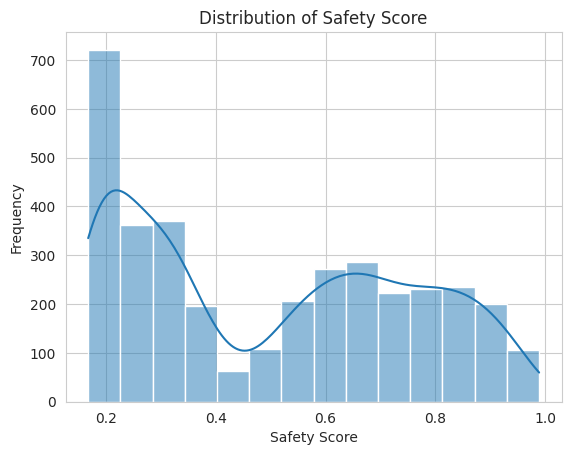

In [142]:
sns.histplot(data=gdf_sss, x='SSS_raw', kde=True)
plt.title('Distribution of Safety Score')
plt.xlabel('Safety Score')
plt.ylabel('Frequency')
plt.show()

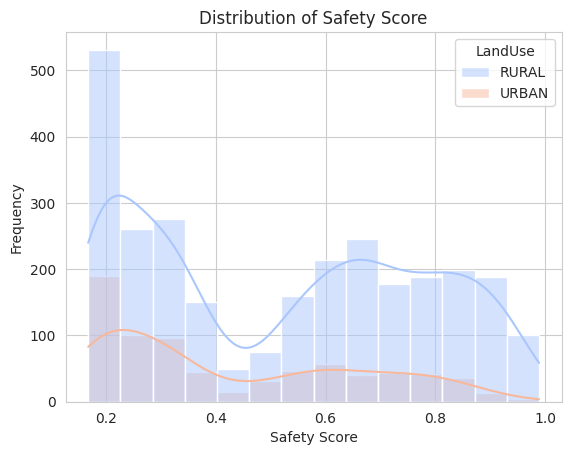

In [143]:
sns.histplot(data=gdf_sss, x='SSS_raw', hue='LandUse', palette='coolwarm', kde=True)
plt.title('Distribution of Safety Score')
plt.xlabel('Safety Score')
plt.ylabel('Frequency')
plt.show()

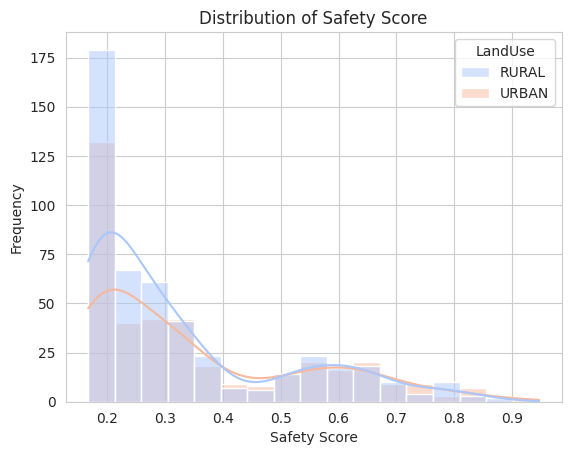

In [152]:
sns.histplot(data=gdf_maharastra, x='SSS_raw', hue='LandUse', palette='coolwarm', kde=True)
plt.title('Distribution of Safety Score')
plt.xlabel('Safety Score')
plt.ylabel('Frequency')
plt.show()

Using outlier removed and cleaned SSS tiers:

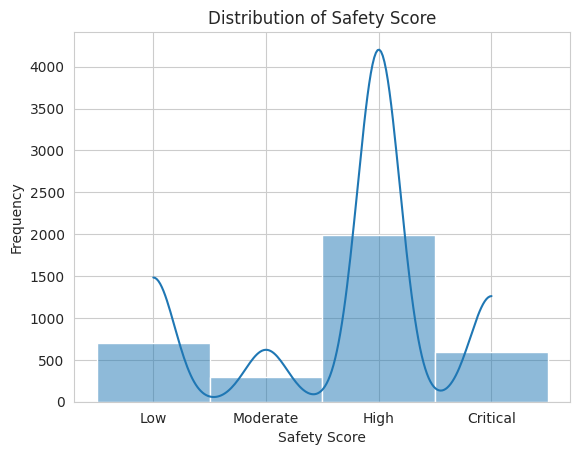

In [145]:
category_order = ['Low', 'Moderate', 'High', 'Critical']
gdf_sss['SSS_Tier'] = pd.Categorical(gdf_sss['SSS_Tier'], categories=category_order, ordered=True)
sns.histplot(data=gdf_sss, x='SSS_Tier', kde=True)
plt.title('Distribution of Safety Score')
plt.xlabel('Safety Score')
plt.ylabel('Frequency')
plt.show()

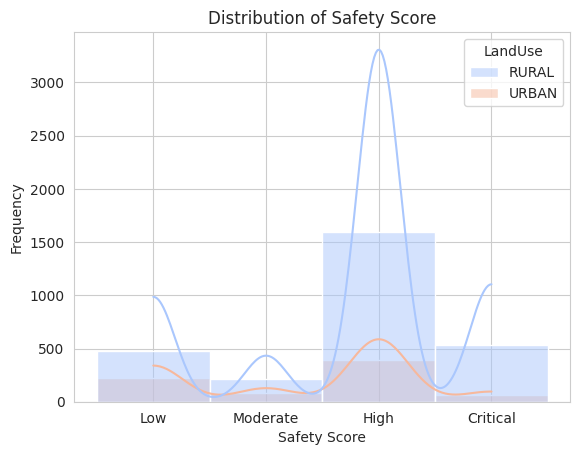

In [146]:
sns.histplot(data=gdf_sss, x='SSS_Tier', hue='LandUse', palette='coolwarm', kde=True)
plt.title('Distribution of Safety Score')
plt.xlabel('Safety Score')
plt.ylabel('Frequency')
plt.show()

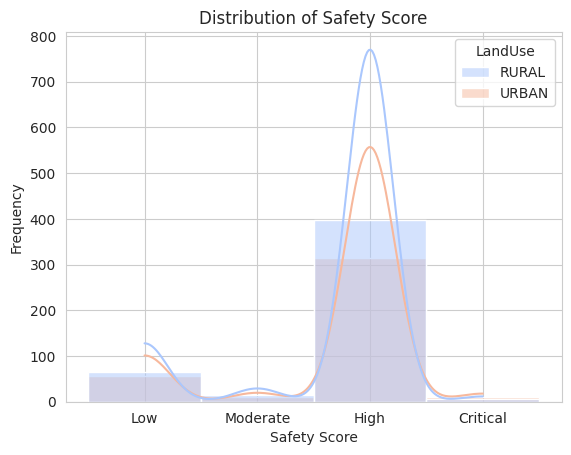

In [154]:
sns.histplot(data=gdf_maharastra, x='SSS_Tier', hue='LandUse', palette='coolwarm', kde=True)
plt.title('Distribution of Safety Score')
plt.xlabel('Safety Score')
plt.ylabel('Frequency')
plt.show()

#Fog and visibility data

##API call

In [113]:
#API setup
geod = Geod(ellps="WGS84")

def geodesic_dist(p1, p2):
    # p1, p2 are shapely Points in lon/lat (EPSG:4326)
    _, _, dist = geod.inv(p1.x, p1.y, p2.x, p2.y)
    return dist  # meters

# ---------------------------------------------------------------------------
# OpenMeteo API Setup
# ---------------------------------------------------------------------------
cache_session = requests_cache.CachedSession('.cache', expire_after=-1)  # cache forever
retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
openmeteo = openmeteo_requests.Client(session=retry_session)

url = "https://historical-forecast-api.open-meteo.com/v1/forecast"

fog_weather_codes = [45, 47, 48]
low_visibility_threshold = 1000  # meters

#looking at past two years
start_date = "2024-06-23"
end_date = "2026-06-22"
daily_vars = ["weather_code", "visibility_min"]

#model metrics
# Function to calculate subgroup metrics, moved here to avoid duplication
def subgroup_metrics(df, group_col):
    rows = []
    for grp, sub in df.groupby(group_col):
        n = len(sub)
        if n < 10:  # too small to trust R²
            r2, rmse = np.nan, np.nan
        else:
            r2 = r2_score(sub['actual'], sub['predicted'])
            rmse = np.sqrt(mean_squared_error(sub['actual'], sub['predicted']))
        rows.append({'group': grp, 'n': n, 'R2': r2, 'RMSE': rmse})
    return pd.DataFrame(rows).sort_values('n', ascending=False)

In [ ]:
# ---------------------------------------------------------------------------
# OpenMeteo API Setup
# ---------------------------------------------------------------------------
cache_session = requests_cache.CachedSession('.cache', expire_after=-1)  # cache forever
retry_session = retry(cache_session, retries=5, backoff_factor=0.2)
openmeteo = openmeteo_requests.Client(session=retry_session)

url = "https://historical-forecast-api.open-meteo.com/v1/forecast"

fog_weather_codes = [45, 47, 48]
low_visibility_threshold = 1000  # meters

#looking at past two years
start_date = "2024-06-23"
end_date = "2026-06-22"
daily_vars = ["weather_code", "visibility_min"]

##For Maharashtra:

In [114]:
#getting unique centroids coordinates to avoid retrying same places
gdf_maharastra['centroid_x'] = gdf_maharastra.geometry.centroid.x
gdf_maharastra['centroid_y'] = gdf_maharastra.geometry.centroid.y
#slight innaccuracy acceptable for weather data

/tmp/ipykernel_915/3410395220.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_maharastra['centroid_x'] = gdf_maharastra.geometry.centroid.x
/tmp/ipykernel_915/3410395220.py:3: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_maharastra['centroid_y'] = gdf_maharastra.geometry.centroid.y


In [116]:
# 1. Spatially deduplicate centroids onto a grid
# ---------------------------------------------------------------------------
# 0.1 degree is roughly 11km at the equator -- matches the global model resolution
GRID_SIZE = 0.1

gdf_maharastra['grid_lat'] = (gdf_maharastra['centroid_y'] / GRID_SIZE).round() * GRID_SIZE
gdf_maharastra['grid_lon'] = (gdf_maharastra['centroid_x'] / GRID_SIZE).round() * GRID_SIZE

raw_unique = gdf_maharastra[['centroid_x', 'centroid_y']].drop_duplicates()
unique_points = gdf_maharastra[['grid_lat', 'grid_lon']].drop_duplicates().reset_index(drop=True)

print(f"Unique road centroids before grid-snapping: {len(raw_unique)}")
print(f"Unique grid points after grid-snapping: {len(unique_points)}")


Unique road centroids before grid-snapping: 920
Unique grid points after grid-snapping: 392


In [117]:
# 2. Estimating call weight BEFORE spending any requests
n_days = (pd.to_datetime(end_date) - pd.to_datetime(start_date)).days
n_vars = len(daily_vars)
estimated_weight = len(unique_points) * (n_days / 14) * (n_vars / 10)

print(f"Date range: {start_date} -> {end_date} ({n_days} days)")
print(f"Estimated total call weight: {estimated_weight:.0f}")
print("Free tier limits: 10,000/day, 5,000/hour, 600/minute")
if estimated_weight > 9000:
    print("WARNING: this is close to (or over) the daily limit. "
          "Consider a coarser GRID_SIZE, a shorter date range, or "
          "splitting the run across multiple days.")


Date range: 2024-06-23 -> 2026-06-22 (729 days)
Estimated total call weight: 4082
Free tier limits: 10,000/day, 5,000/hour, 600/minute


In [120]:
# 3. Batch requests in chunks, pacing between chunks
# ---------------------------------------------------------------------------
# Chunk size chosen so a single chunk's weight stays well under the 600/min
# cap. Tune based on your own n_days/n_vars if you change the date range.
CHUNK_SIZE = 50
SLEEP_BETWEEN_CHUNKS = 10  # seconds

location_weather_counts_maharastra = [] # Renamed to prevent conflict with Thailand
points = unique_points.to_dict('records')

for i in range(0, len(points), CHUNK_SIZE):
    chunk = points[i:i + CHUNK_SIZE]

    params = {
        "latitude": [p['grid_lat'] for p in chunk],
        "longitude": [p['grid_lon'] for p in chunk],
        "start_date": start_date,
        "end_date": end_date,
        "daily": daily_vars,
    }

    responses = openmeteo.weather_api(url, params=params)

    for response, point in zip(responses, chunk):
        daily = response.Daily()
        daily_weather_code = daily.Variables(0).ValuesAsNumpy()
        daily_visibility_min = daily.Variables(1).ValuesAsNumpy()

        fog_warnings_count = int(np.isin(daily_weather_code, fog_weather_codes).sum())
        low_visibility_count = int((daily_visibility_min < low_visibility_threshold).sum())

        location_weather_counts_maharastra.append({
            'grid_lat': point['grid_lat'],
            'grid_lon': point['grid_lon'],
            'fog_warnings_count': fog_warnings_count,
            'low_visibility_count': low_visibility_count,
        })

    print(f"Processed {min(i + CHUNK_SIZE, len(points))}/{len(points)} grid points for Maharashtra")
    time.sleep(SLEEP_BETWEEN_CHUNKS)

aggregated_weather_analysis_maharastra = pd.DataFrame(location_weather_counts_maharastra)

Processed 50/392 grid points for Maharashtra
Processed 100/392 grid points for Maharashtra
Processed 150/392 grid points for Maharashtra
Processed 200/392 grid points for Maharashtra
Processed 250/392 grid points for Maharashtra
Processed 300/392 grid points for Maharashtra
Processed 350/392 grid points for Maharashtra
Processed 392/392 grid points for Maharashtra


In [121]:
# 4. Join the grid-level results back onto every road
gdf_maharastra = gdf_maharastra.merge(
    aggregated_weather_analysis_maharastra, # Using renamed variable
    on=['grid_lat', 'grid_lon'],
    how='left'
)
print("\nAggregated Fog and Low Visibility Counts for Maharashtra:\n")
print(aggregated_weather_analysis_maharastra.head())


Aggregated Fog and Low Visibility Counts for Maharashtra:

   grid_lat  grid_lon  fog_warnings_count  low_visibility_count
0      19.2      76.6                   0                     0
1      18.4      76.9                   0                     2
2      18.2      76.6                   0                     5
3      18.3      76.9                   0                     1
4      19.4      80.1                   0                    16


In [122]:
gdf_maharastra['fog_warnings_count'].value_counts()

,count
fog_warnings_count,
0,920


In [123]:
gdf_maharastra['low_visibility_count'].value_counts()

,count
low_visibility_count,
3,70
1,65
0,64
4,49
2,44
...,...
30,1
179,1
243,1


##For Thailand:

In [124]:
#getting unique centroids coordinates to avoid retrying same places
gdf_thailand['centroid_x'] = gdf_thailand.geometry.centroid.x
gdf_thailand['centroid_y'] = gdf_thailand.geometry.centroid.y
#slight innaccuracy acceptable for weather data

/tmp/ipykernel_915/926499355.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_thailand['centroid_x'] = gdf_thailand.geometry.centroid.x
/tmp/ipykernel_915/926499355.py:3: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_thailand['centroid_y'] = gdf_thailand.geometry.centroid.y


Increased Grid size for computation purposes and since Thailand is ~200,000 sqkm larger than maharashtra

In [125]:
# 1. Spatially deduplicate centroids onto a grid
# ---------------------------------------------------------------------------
# 0.1 degree is roughly 11km at the equator -- matches the global model
# resolution. Use a smaller value (e.g. 0.05) if you need finer fidelity,
# at the cost of more unique points/more weight.
GRID_SIZE = 0.29

gdf_thailand['grid_lat'] = (gdf_thailand['centroid_y'] / GRID_SIZE).round() * GRID_SIZE
gdf_thailand['grid_lon'] = (gdf_thailand['centroid_x'] / GRID_SIZE).round() * GRID_SIZE

raw_unique = gdf_thailand[['centroid_x', 'centroid_y']].drop_duplicates()
unique_points = gdf_thailand[['grid_lat', 'grid_lon']].drop_duplicates().reset_index(drop=True)

print(f"Unique road centroids before grid-snapping: {len(raw_unique)}")
print(f"Unique grid points after grid-snapping:      {len(unique_points)}")

Unique road centroids before grid-snapping: 11134
Unique grid points after grid-snapping:      530


In [126]:
# 2. Estimating call weight BEFORE spending any requests
n_days = (pd.to_datetime(end_date) - pd.to_datetime(start_date)).days
n_vars = len(daily_vars)
estimated_weight = len(unique_points) * (n_days / 14) * (n_vars / 10)

print(f"Date range: {start_date} -> {end_date} ({n_days} days)")
print(f"Estimated total call weight: {estimated_weight:.0f}")
print("Free tier limits: 10,000/day, 5,000/hour, 600/minute")
if estimated_weight > 9000:
    print("WARNING: this is close to (or over) the daily limit. "
          "Consider a coarser GRID_SIZE, a shorter date range, or "
          "splitting the run across multiple days.")

Date range: 2024-06-23 -> 2026-06-22 (729 days)
Estimated total call weight: 5520
Free tier limits: 10,000/day, 5,000/hour, 600/minute


In [155]:
# 3. Batch requests in chunks, pacing between chunks
# ---------------------------------------------------------------------------
# Chunk size chosen so a single chunk's weight stays well under the 600/min
# cap. Tune based on your own n_days/n_vars if you change the date range.
CHUNK_SIZE = 25  # Reduced chunk size
SLEEP_BETWEEN_CHUNKS = 25  # Increased sleep time to prevent API limit issues

location_weather_counts_thailand = [] # New variable for Thailand data
points_thailand = unique_points.to_dict('records') # Renamed to avoid using 'points' from Maharashtra

for i in range(0, len(points_thailand), CHUNK_SIZE):
    chunk = points_thailand[i:i + CHUNK_SIZE]

    params = {
        "latitude": [p['grid_lat'] for p in chunk],
        "longitude": [p['grid_lon'] for p in chunk],
        "start_date": start_date,
        "end_date": end_date,
        "daily": daily_vars,
    }

    responses = openmeteo.weather_api(url, params=params)

    for response, point in zip(responses, chunk):
        daily = response.Daily()
        daily_weather_code = daily.Variables(0).ValuesAsNumpy()
        daily_visibility_min = daily.Variables(1).ValuesAsNumpy()

        fog_warnings_count = int(np.isin(daily_weather_code, fog_weather_codes).sum())
        low_visibility_count = int((daily_visibility_min < low_visibility_threshold).sum())

        location_weather_counts_thailand.append({
            'grid_lat': point['grid_lat'],
            'grid_lon': point['grid_lon'],
            'fog_warnings_count': fog_warnings_count,
            'low_visibility_count': low_visibility_count,
        })

    print(f"Processed {min(i + CHUNK_SIZE, len(points_thailand))}/{len(points_thailand)} grid points for Thailand")
    time.sleep(SLEEP_BETWEEN_CHUNKS)

aggregated_weather_analysis_thailand = pd.DataFrame(location_weather_counts_thailand)

Processed 25/530 grid points for Thailand
Processed 50/530 grid points for Thailand
Processed 75/530 grid points for Thailand
Processed 100/530 grid points for Thailand
Processed 125/530 grid points for Thailand
Processed 150/530 grid points for Thailand
Processed 175/530 grid points for Thailand
Processed 200/530 grid points for Thailand
Processed 225/530 grid points for Thailand
Processed 250/530 grid points for Thailand
Processed 275/530 grid points for Thailand
Processed 300/530 grid points for Thailand
Processed 325/530 grid points for Thailand
Processed 350/530 grid points for Thailand
Processed 375/530 grid points for Thailand
Processed 400/530 grid points for Thailand
Processed 425/530 grid points for Thailand
Processed 450/530 grid points for Thailand
Processed 475/530 grid points for Thailand
Processed 500/530 grid points for Thailand
Processed 525/530 grid points for Thailand
Processed 530/530 grid points for Thailand


In [156]:
# 4. Join the grid-level results back onto every road
gdf_thailand = gdf_thailand.merge(
    aggregated_weather_analysis_thailand, # Using renamed variable for Thailand
    on=['grid_lat', 'grid_lon'],
    how='left'
)
print("\nAggregated Fog and Low Visibility Counts for Thailand:\n")
print(aggregated_weather_analysis_thailand.head())


Aggregated Fog and Low Visibility Counts for Thailand:

   grid_lat  grid_lon  fog_warnings_count  low_visibility_count
0     14.79    103.53                   0                     3
1     15.08    103.53                   0                     4
2     13.92    100.63                   0                     5
3     16.53    102.95                   0                     3
4     13.63    100.34                   0                     4


In [157]:
gdf_thailand['fog_warnings_count'].isna().sum()

np.int64(0)

In [158]:
gdf_thailand['fog_warnings_count'].value_counts()

,count
fog_warnings_count,
0,11134


In [159]:
gdf_thailand['low_visibility_count'].isna().sum()

np.int64(0)

In [160]:
gdf_thailand['low_visibility_count'].value_counts()

,count
low_visibility_count,
5,780
4,745
2,724
3,646
0,532
...,...
145,1
287,1
123,1


#Analytical Model

##Analytical model

### Standardizing Feature Names

Uncomment when running for the first time

In [164]:
gdf_maharastra.rename(columns={'names_primary': 'road_name', 'Sample_Size_Total': 'total_sample_size'}, inplace=True)
gdf_thailand.rename(columns={'english_ro': 'road_name', 'SampleSizeTotal': 'total_sample_size'}, inplace=True)

# Drop 'NumberOverLimit' from both datasets as 'PercentOverLimit' is a better feature
#gdf_maharastra.drop(columns=['NumberOverLimit'], inplace=True)
#gdf_thailand.drop(columns=['NumberOverLimit'], inplace=True)

# Drop 'ForAnalysis' from gdf_thailand as it appears redundant with SpeedLimit
#gdf_thailand.drop(columns=['ForAnalysis'], inplace=True)

# Dropping additional columns identified during initial cleaning
#gdf_maharastra.drop(['DISSOLVE_ID', 'Pass', 'subtype', 'ExcludeFromSpeedSPI','class', 'SpeedLimitFloor','Percent_'], axis='columns', inplace=True)
# 'RoadLength' was dropped implicitly by using Shape_Length, if it was still present it should be dropped as redundant

columns_to_drop_thailand_initial = ['OvertureID', 'SpeedLimitFloor','Percent_']
existing_columns_to_drop_thailand_initial = [col for col in columns_to_drop_thailand_initial if col in gdf_thailand.columns]
gdf_thailand.drop(existing_columns_to_drop_thailand_initial, axis='columns', inplace=True)
# 'RoadLength' was dropped implicitly by using Shape_Length, if it was still present it should be dropped as redundant
# 'NO_OF_Result_Segments' was dropped with other NaNs, if it were present it should be dropped here.

In [ ]:
gdf_maharastra.rename(columns={'names_primary': 'road_name', 'Sample_Size_Total': 'total_sample_size'}, inplace=True)
gdf_thailand.rename(columns={'english_ro': 'road_name', 'SampleSizeTotal': 'total_sample_size'}, inplace=True)

columns_to_drop_thailand_initial = ['OvertureID', 'SpeedLimitFloor','Percent_']
existing_columns_to_drop_thailand_initial = [col for col in columns_to_drop_thailand_initial if col in gdf_thailand.columns]
gdf_thailand.drop(existing_columns_to_drop_thailand_initial, axis='columns', inplace=True)

In [165]:
print('Columns in gdf_maharastra after standardization:')
print(gdf_maharastra.columns.tolist())
print('\nColumns in gdf_thailand after standardization:')
print(gdf_thailand.columns.tolist())

Columns in gdf_maharastra after standardization:
['road_name', 'UrbanPC', 'SampleSize_avg', 'WeightedSample', 'Percentile', 'SpeedLimit', 'RoadClass', 'LandUse', 'MedianSpeed', 'F85thPercentileSpeed', 'PercentileBand', 'RankedPercentile', 'total_sample_size', 'PercentOverLimit', 'StreetImageLink', 'Shape_Length', 'geometry', 'centroid_x', 'centroid_y', 'grid_lat', 'grid_lon', 'fog_warnings_count', 'low_visibility_count', 'SSS_raw', 'SSS_Tier', 'sinuosity']

Columns in gdf_thailand after standardization:
['road_name', 'SampleSize_avg', 'WeightedSample', 'Percentile', 'SpeedLimit', 'RoadClass', 'MedianSpeed', 'F85thPercentileSpeed', 'ProvinceID', 'PercentOverLimit', 'InvPercentile', 'AnalysisStatus', 'RankedPercentile', 'StreetImageLink', 'LandUse', 'PercentileBand', 'total_sample_size', 'Shape_Length', 'geometry', 'centroid_x', 'centroid_y', 'grid_lat', 'grid_lon', 'fog_warnings_count', 'low_visibility_count']


Two slightly different models are created for Maharashtra and Thailand, since the VRU_Exposure_Index was only calculated for Maharashtra

In [166]:
import xgboost as xgb
from sklearn.model_selection import train_test_split

###For Maharashtra:

In [167]:
gdf_maharastra['Shape_Length'] = gdf_maharastra['Shape_Length'].apply(np.round)

In [168]:
gdf_maharastra.columns.tolist()

['road_name',
 'UrbanPC',
 'SampleSize_avg',
 'WeightedSample',
 'Percentile',
 'SpeedLimit',
 'RoadClass',
 'LandUse',
 'MedianSpeed',
 'F85thPercentileSpeed',
 'PercentileBand',
 'RankedPercentile',
 'total_sample_size',
 'PercentOverLimit',
 'StreetImageLink',
 'Shape_Length',
 'geometry',
 'centroid_x',
 'centroid_y',
 'grid_lat',
 'grid_lon',
 'fog_warnings_count',
 'low_visibility_count',
 'SSS_raw',
 'SSS_Tier',
 'sinuosity']

In [175]:
#derive target from speed safety score
#y_m = gdf_maharastra['SSS_Tier'].astype('category').cat.codes

In [264]:
# First, create a working copy of gdf_maharastra for the modeling task
# This ensures that operations here don't affect other parts of the notebook unexpectedly
gdf_maharastra_model = gdf_maharastra.copy()

m_features = [
    #'sinuosity', exluding since sinuosity is used in the Safe Speed Score Calculation
    'low_visibility_count',
    'Shape_Length',
    'VRU_exposure_index',
    'RoadClass',
    'poi_score',
    'crossing_score',
    'footfall_score',
    'LandUse',
    'SSS_Tier',
]
target_column = 'F85thPercentileSpeed'

# Ensure all relevant columns (features and target) are present for cleaning
# Also, add 'total_sample_size' to the cleaning subset as it's used for sample weights
# and could contain NaNs that would affect the rows being used.
all_model_columns = m_features + [target_column, 'total_sample_size']

# Drop rows where any of the selected features or the target column have NaN values
gdf_maharastra_model.dropna(subset=all_model_columns, inplace=True)

# Now derive X_m and y_m from the cleaned DataFrame
X_m = gdf_maharastra_model[m_features].copy()
y_m = gdf_maharastra_model[target_column]

# Convert 'RoadClass' and 'LandUse' to numerical representation
# These columns are converted *after* dropna
X_m['RoadClass'] = X_m['RoadClass'].astype('category').cat.codes
X_m['LandUse'] = X_m['LandUse'].astype('category').cat.codes
X_m['SSS_Tier'] = X_m['SSS_Tier'].astype('category').cat.codes
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_m, y_m, test_size=0.2, random_state=42)

# Ensure sample weights are also derived from the cleaned gdf_maharastra_model
sample_weight_train = gdf_maharastra_model['total_sample_size'].loc[X_train.index]
sample_weight_test = gdf_maharastra_model['total_sample_size'].loc[X_test.index]


In [265]:
m_model = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,       # slow learner = more robust
    max_depth=6,              # shallow trees generalise better on small data
    subsample=0.8,            # row subsampling like RF
    colsample_bytree=0.8,     # feature subsampling like RF
    reg_alpha=0.1,            # L1 regularisation
    reg_lambda=1.0,           # L2 regularisation
    early_stopping_rounds=20, # stops when validation loss plateaus
    #scale_pos_weight=1.0,     # handles class imbalance
    enable_categorical=True,  # Enable categorical features
    eval_metric="rmse",      # Changed evaluation metric for classification
    random_state=42           # Added for reproducibility
)

In [266]:
sample_weight_train = gdf_maharastra['total_sample_size'].loc[X_train.index]
sample_weight_test = gdf_maharastra['total_sample_size'].loc[X_test.index]
m_model.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)],
            sample_weight=sample_weight_train, sample_weight_eval_set=[sample_weight_train, sample_weight_test], verbose=False)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=20,
             enable_categorical=True, eval_metric='rmse', feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [268]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

predictions = m_model.predict(X_test)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)

print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

Root Mean Squared Error (RMSE): 12.54
R-squared (R2): 0.30


The model produces a fairly low R squared value, meaning that it is only able to explain ~30% of the variance of the distribution

###Comparing Models

In [269]:
X = X_m.copy()
y = y_m

# Explicitly ensure categorical features are numerically encoded for X
# This is a defensive step to ensure RandomForestRegressor receives numerical input.
for col in ['RoadClass', 'LandUse']:
    if X[col].dtype == 'object' or X[col].dtype.name == 'category':
        X[col] = X[col].astype('category').cat.codes

df = gdf_maharastra

kf = KFold(n_splits=5, shuffle=True, random_state=42)

def manual_cv_predict(model_factory, X, y, kf):
    """model_factory: a no-arg function that returns a FRESH, unfitted model each call."""
    oof = np.zeros(len(y))
    for train_idx, val_idx in kf.split(X):
        model = model_factory()
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train = y.iloc[train_idx]
        model.fit(X_train, y_train)
        oof[val_idx] = model.predict(X_val)
    return oof

model_factories = {
    'XGBoost (current)': lambda: clone(m_model).set_params(early_stopping_rounds=None),
    'CatBoost': lambda: CatBoostRegressor(
        iterations=300, learning_rate=0.05, depth=4,
        verbose=0, random_state=42,
        cat_features=['RoadClass', 'LandUse']
    ),
    'RandomForest': lambda: RandomForestRegressor(
        n_estimators=300, max_depth=6, min_samples_leaf=5, random_state=42
    ),
}

results = {}
for name, factory in model_factories.items():
    preds = manual_cv_predict(factory, X, y, kf)
    results[name] = {
        'R2_overall': r2_score(y, preds),
        'RMSE_overall': np.sqrt(mean_squared_error(y, preds)),
    }
    tmp = pd.DataFrame({'actual': y.values, 'pred': preds, 'LandUse': df.loc[X.index, 'LandUse'].values})
    for grp, sub in tmp.groupby('LandUse'):
        results[name][f'R2_{grp}'] = r2_score(sub['actual'], sub['pred'])
        results[name][f'RMSE_{grp}'] = np.sqrt(mean_squared_error(sub['actual'], sub['pred']))

print(pd.DataFrame(results).T.round(3))


                   R2_overall  RMSE_overall  R2_RURAL  RMSE_RURAL  R2_URBAN  \
XGBoost (current)       0.310        14.877     0.303      14.113     0.005   
CatBoost                0.344        14.512     0.312      14.024     0.094   
RandomForest            0.311        14.870     0.301      14.139     0.012   

                   RMSE_URBAN  
XGBoost (current)      15.903  
CatBoost               15.179  
RandomForest           15.853  


This ranking points to choice of model:
XGBoost < RandomForest< CatBoost and also interestingly, that all three models perform significantly better for Rural Areas rather than Urban ones

Checking how stable this ranking is, ie how resistant to noise the models are:

In [270]:
seeds = [0, 1, 2, 3, 4]
stability = {name: [] for name in model_factories}

for seed in seeds:
    kf_seed = KFold(n_splits=5, shuffle=True, random_state=seed)
    for name, factory in model_factories.items():
        preds = manual_cv_predict(factory, X, y, kf_seed)
        stability[name].append(r2_score(y, preds))

for name, scores in stability.items():
    print(f"{name}: mean R2 = {np.mean(scores):.3f}, std = {np.std(scores):.3f}")

XGBoost (current): mean R2 = 0.228, std = 0.073
CatBoost: mean R2 = 0.256, std = 0.029
RandomForest: mean R2 = 0.280, std = 0.025


This shows that random forest is, on average, the best here.

###Model Evaluation

In [290]:
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_squared_error

baseline = DummyRegressor(strategy="mean").fit(X_train, y_train)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline.predict(X_test)))
print(f"Baseline RMSE: {baseline_rmse:.3f} vs Model RMSE: 12.54")

Baseline RMSE: 18.183 vs Model RMSE: 12.54


The XGBoost Model does beat a predict-the-mean result, without overtly suggesting overfitting

Checking for overfitting by plotting the performance of the model.

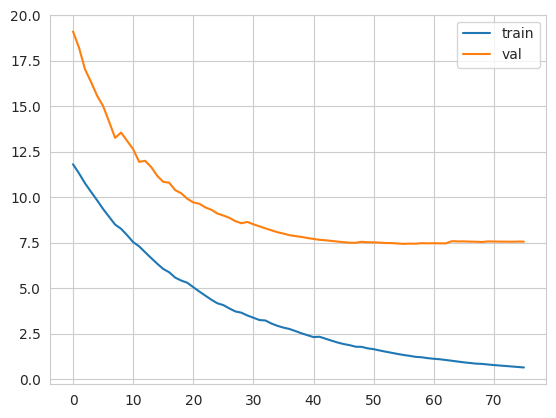

In [273]:
results = m_model.evals_result()
import matplotlib.pyplot as plt
plt.plot(results['validation_0']['rmse'], label='train')
plt.plot(results['validation_1']['rmse'], label='val')
plt.legend(); plt.show()

The training and validation RMSE curves decrease significantly in the initial rounds, indicating that the model is learning effectively. After approximately 40-50 rounds, the validation curve plateaus around 7.5, even though the training curve continues to decrease. **This suggests that the model starts to overfit the training data after around 40-50 boosting rounds, and the early_stopping_rounds=20 parameter would have stopped the training around this point**

Plotting Residuals

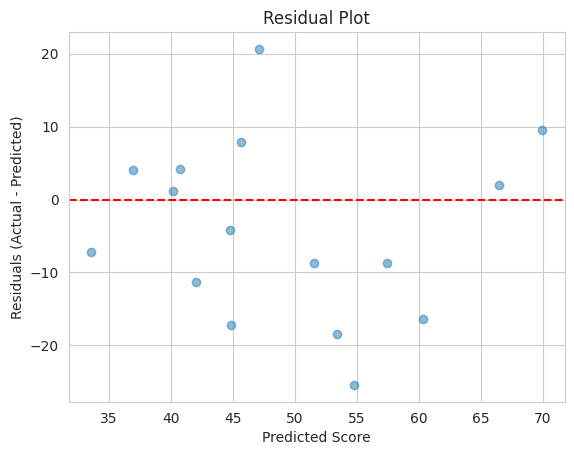

In [285]:
import matplotlib.pyplot as plt

predictions = m_model.predict(X_test)
residuals = y_test - predictions

plt.scatter(predictions, residuals, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Score')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residual Plot')
plt.show()

Ideally the residuals should be **randomly scattered around the horizontal line at zero**, and that appears to be the case here, with no discernable pattern observed, though due to the limited number of data points does not allow for better statements about randomness

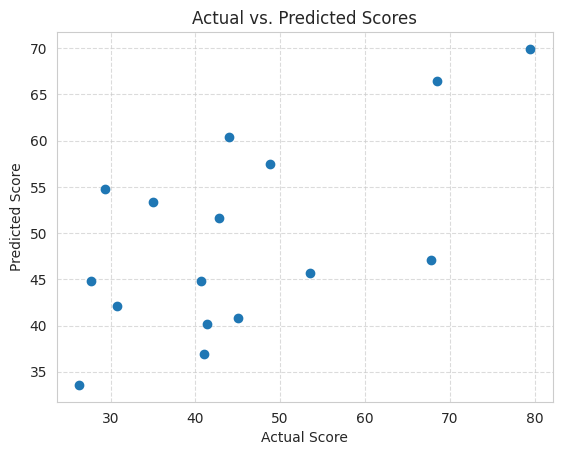

In [280]:
import matplotlib.pyplot as plt
plt.scatter(y_test, m_model.predict(X_test))
plt.xlabel('Actual Score'); plt.ylabel('Predicted Score')
plt.title('Actual vs. Predicted Scores')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

For a perfect predictor, x=y and a completely linear plot would be observed. While not the case here, a somewhat linear pattern can be observed.

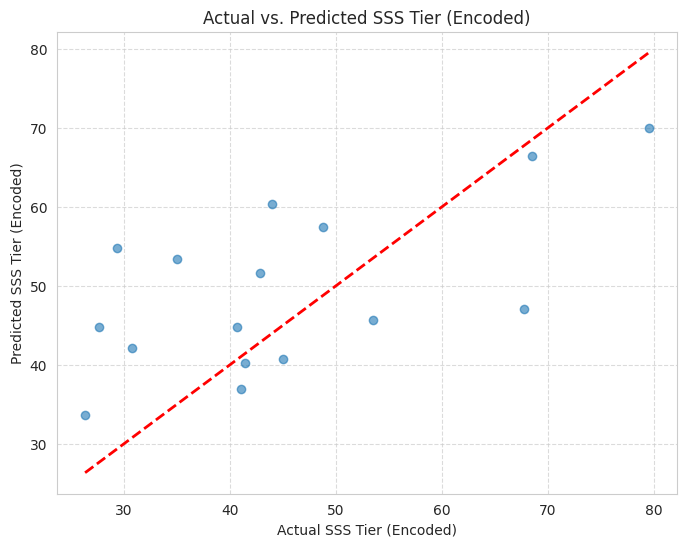

In [281]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_test, predictions, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Line for perfect prediction
plt.xlabel('Actual SSS Tier (Encoded)')
plt.ylabel('Predicted SSS Tier (Encoded)')
plt.title('Actual vs. Predicted SSS Tier (Encoded)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Checking Model for Thailand

##For Thailand

Due to tool limitations, a model with a speed safety score was not created for the Thailand data. This model is moreso for demonstration purposes

The VRU Exposure Index and Speed Safety Score data were only available for Maharashtra. Therefore, a model incorporating these features could not be created for the Thailand dataset. This model serves primarily for demonstrating the predictive capabilities with available features.

In [287]:
y_t = gdf_thailand['F85thPercentileSpeed']

# Select appropriate numerical features for the model, excluding VRU and low_visibility_count data not available/populated for Thailand
t_features = [
    'low_visibility_count',
    'Shape_Length',
    'RoadClass',
    'LandUse',
]
X_t = gdf_thailand[t_features].copy()

# Convert 'RoadClass' and 'LandUse' to numerical representation
X_t['RoadClass'] = X_t['RoadClass'].astype('category').cat.codes
X_t['LandUse'] = X_t['LandUse'].astype('category').cat.codes

X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(X_t, y_t, test_size=0.2, random_state=42)

t_model = xgb.XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    early_stopping_rounds=20,
    enable_categorical=True,
    eval_metric="rmse"
)

sample_weight_train_t = gdf_thailand['total_sample_size'].loc[X_train_t.index]
sample_weight_test_t = gdf_thailand['total_sample_size'].loc[X_test_t.index]

t_model.fit(X_train_t, y_train_t, eval_set=[(X_train_t, y_train_t), (X_test_t, y_test_t)], sample_weight=sample_weight_train_t, sample_weight_eval_set=[sample_weight_train_t, sample_weight_test_t], verbose=False)

predictions_t = t_model.predict(X_test_t)
mse_t = mean_squared_error(y_test_t, predictions_t)
rmse_t = np.sqrt(mse_t)
r2_t = r2_score(y_test_t, predictions_t)

print(f"Root Mean Squared Error (RMSE) for Thailand model: {rmse_t:.2f}")
print(f"R-squared (R2) for Thailand model: {r2_t:.2f}")

Root Mean Squared Error (RMSE) for Thailand model: 14.67
R-squared (R2) for Thailand model: 0.36


In [288]:
# Out-of-fold predictions across the FULL dataset for the Thailand model
kf_t = KFold(n_splits=5, shuffle=True, random_state=42)

# Clone the model and disable early stopping for cross_val_predict
model_for_cv_t = clone(t_model)
model_for_cv_t.set_params(early_stopping_rounds=None)

oof_preds_t = cross_val_predict(model_for_cv_t, X_t, y_t, cv=kf_t)

results_df_t = pd.DataFrame({
    'actual': y_t,
    'predicted': oof_preds_t,
    'RoadClass': gdf_thailand.loc[X_t.index, 'RoadClass'],
    'LandUse': gdf_thailand.loc[X_t.index, 'LandUse']
})

In [289]:
print("Thailand Model Performance By LandUse:")
print(subgroup_metrics(results_df_t, 'LandUse'))

print("\nThailand Model Performance By RoadClass x LandUse:")
print(subgroup_metrics(results_df_t, ['RoadClass', 'LandUse']))

Thailand Model Performance By LandUse:
   group     n        R2       RMSE
1  URBAN  5593  0.293218  15.762552
0  RURAL  5541  0.370584  13.757567

Thailand Model Performance By RoadClass x LandUse:
                group     n        R2       RMSE
4  (secondary, RURAL)  3076  0.117979  14.206661
5  (secondary, URBAN)  2764  0.126883  16.218311
3    (primary, URBAN)  1779  0.102168  16.019014
2    (primary, RURAL)  1377  0.105093  13.527072
6      (trunk, RURAL)  1070  0.108054  12.738425
7      (trunk, URBAN)   939  0.077899  13.986666
1   (motorway, URBAN)   111  0.292688  14.205787
0   (motorway, RURAL)    18  0.564819  11.377414


The Thailand model also shows better R-squared values for rural regions

###Model Evaluation for Thailand

In [292]:

baseline = DummyRegressor(strategy="mean").fit(X_train_t, y_train_t)
baseline_rmse = np.sqrt(mean_squared_error(y_test_t, baseline.predict(X_test_t)))
print(f"Baseline RMSE: {baseline_rmse:.3f} vs Model RMSE: {rmse_t:.2f}")

Baseline RMSE: 18.347 vs Model RMSE: 14.67


The XGBoost Model does beat a predict-the-mean result, without overtly suggesting overfitting

Checking for overfitting by plotting the performance of the model.

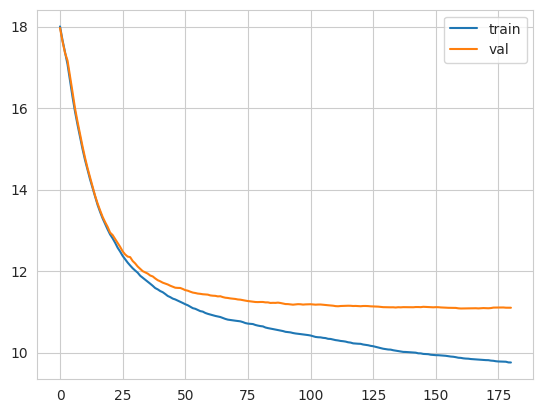

In [293]:
results = t_model.evals_result()
plt.plot(results['validation_0']['rmse'], label='train')
plt.plot(results['validation_1']['rmse'], label='val')
plt.legend(); plt.show()

The training and validation RMSE curves decrease significantly in the initial rounds, indicating that the model is learning effectively. After approximately 50-75 rounds, the validation curve plateaus and rmse values remain higher than the trainig set.  **This suggests that the model starts to overfit the training data and the early_stopping_rounds=20 parameter would have stopped the training around this point**

Plotting Residuals

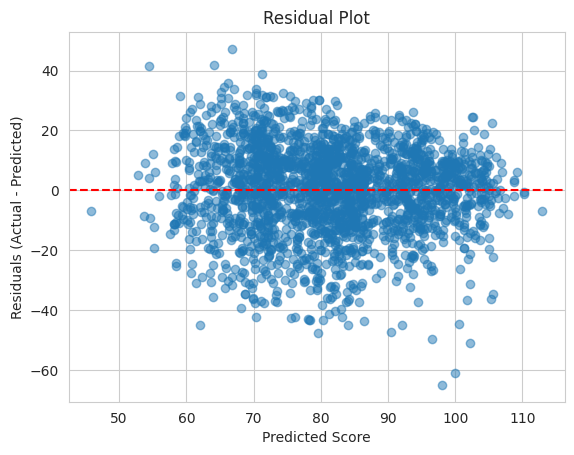

In [295]:

predictions = t_model.predict(X_test_t)
residuals = y_test_t - predictions

plt.scatter(predictions, residuals, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Score')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residual Plot')
plt.show()

Ideally the residuals should be **randomly scattered around the horizontal line at zero**, and since no obvious pattern is observable, the linearity assumption is met.

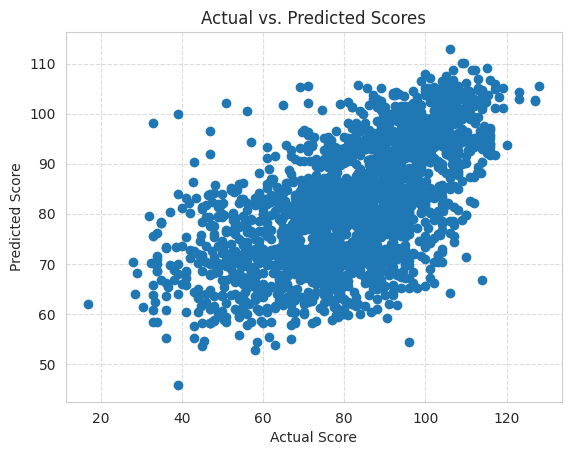

In [300]:
plt.scatter(y_test_t, t_model.predict(X_test_t))
plt.xlabel('Actual Score'); plt.ylabel('Predicted Score')
plt.title('Actual vs. Predicted Scores')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

For a perfect predictor, x=y and a completely linear plot would be observed. While not the case here, a somewhat linear pattern can be observed.

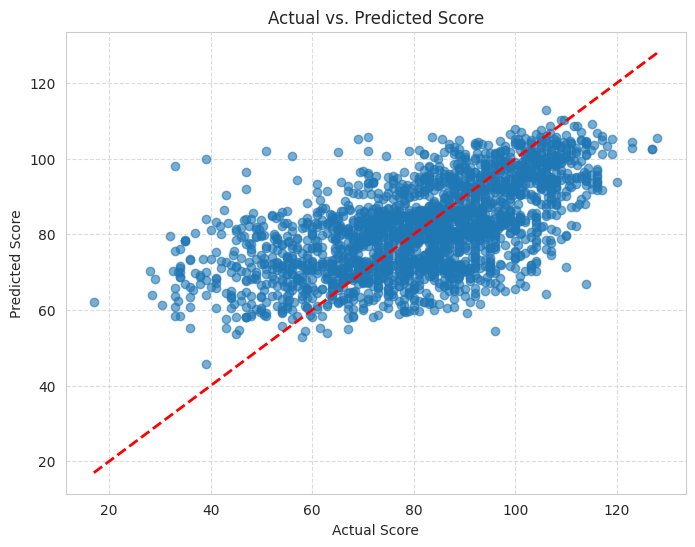

In [301]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test_t, predictions, alpha=0.6)
plt.plot([y_test_t.min(), y_test_t.max()], [y_test_t.min(), y_test_t.max()], 'r--', lw=2) # Line for perfect prediction
plt.xlabel('Actual Score')
plt.ylabel('Predicted Score')
plt.title('Actual vs. Predicted Score')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

There's a positive correlation between actual and predicted scores, meaning that as actual speeds increase, the predicted speeds also tend to increase. However, the points are **not perfectly aligned with the red line, indicating that there is still some error in the predictions.** The spread of the points around the line suggests the model has some variability in its prediction

## Conclusion

This notebook successfully demonstrates a comprehensive road safety analysis workflow, from data loading and cleaning to advanced modeling and evaluation for two distinct regions: Maharashtra and Thailand. We integrated various data sources, including geographic features, VRU exposure indices, speed safety scores, and historical weather data, to build predictive models for the F85th Percentile Speed. While the models show moderate predictive power (R-squared values around 0.30-0.36), outperforming baseline dummy regressors, there is potential for further improvement by exploring more advanced feature engineering, alternative model architectures, or access to more granular and diverse datasets. The analysis also highlighted interesting regional differences, particularly in how factors like land use influence model performance.